# Система прогнозирования продаж для «Прилавка»

**Автор:** Сергей Базавлук

**Дата:** Май 2026

## Описание задачи

Наш клиент — компания «Прилавок», новая сеть дарксторов в России, специализирующаяся на быстрой доставке продуктов и товаров повседневного спроса. Компания работает с 2023 года и управляет более чем 45 дарксторами.

**Бизнес-проблема**

Эффективность дарксторов критически зависит от точности управления запасами. Текущая система планирования закупок работает на субъективных оценках аналитиков, что приводит к разным проблемам:
- К дефициту товаров в пиковые периоды (недополучение 3–5% выручки).
- К избыточным запасам и списаниям продуктов с коротким сроком годности (2–3% от выручки).
- К неэффективному использованию времени аналитиков (15–20 часов в неделю на ручное планирование).

**Цель проекта**

Разработать автоматизированную систему прогнозирования недельных продаж для каждого отдела во всех дарксторах с использованием машинного обучения (модель CatBoost). Система будет работать в режиме пакетного внедрения с недельным циклом: модель будет переобучаться каждое воскресенье вечером, а к понедельнику утром прогнозы будут готовы для передачи в систему планирования закупок.

## Описание данных

Для работы доступны исторические данные о продажах за февраль 2023 — октябрь 2025, организованные в виде нескольких таблиц в PostgreSQL:

1. Таблица `sales` — исторические данные о продажах:
   - `Store` — номер даркстора (1–45).
   - `Dept` — номер отдела внутри даркстора (1–99).
   - `Date` — неделя (дата начала недели).
   - `Weekly_Sales` — недельные продажи (руб., целевая переменная).
   - `IsHoliday` — признак праздничной недели.

2. Таблица `stores` — информация о дарксторах:
   - `Store` — номер даркстора.
   - `Type` — тип даркстора (A, B, C).
   - `Size` — размер даркстора в условных единицах.

3. Таблица `features` — внешние факторы:
   - `Store`, `Date` — идентификаторы.
   - `Temperature` — средняя температура за неделю.
   - `Fuel_Price` — средняя цена бензина.
   - `MarkDown1-5` — факторы рекламных акций и скидок.
   - `CPI` — индекс потребительских цен.
   - `Unemployment` — уровень безработицы.

4. Таблица `plan` — данные для инференса (ноябрь 2025 — июль 2026), содержит те же столбцы, что и `sales`, кроме `Weekly_Sales`.

## План работы

Проект состоит из двух частей. В этом ноутбуке вы выполните первую:

1. Первичный анализ и очистка данных.
2. Предобработка и создание признаков.
3. Мониторинг стабильности признаков (PSI).
4. Обучение модели CatBoost и оценка качества.



In [1]:
!pip install dotenv -q
!pip install phik -q
!pip install python-dotenv boto3 -q
!pip install optuna -q

In [2]:
# Здесь все необходимые импорты
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import phik
import seaborn as sns
import psycopg2
import os
import io
import pickle
import boto3
import optuna

from IPython.display import HTML, display
from sqlalchemy import create_engine
from dotenv import load_dotenv
from catboost import CatBoostRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

Фиксируем `random_state` для воспроизводимости результатов.

In [3]:
RANDOM_STATE = 42

### Шаг 1. Первичный анализ данных

**Задача:** подключитесь к базе данных PostgreSQL и загрузите данные для анализа.

**Важно:** не храните креды в коде! Используйте переменные окружения или Airflow Variables и Connections.

In [4]:
# Узнаем текущую директорию
current_dir = os.getcwd()
print(f"Текущая директория: {current_dir}")

# Загружаем .env из текущей директории
load_dotenv(dotenv_path='./.env')

# Проверяем
print(os.getenv('DB_USER'))

Текущая директория: /home/jovyan/work
ds_20260421_d53f8171a0


**Задача:** загрузите три таблицы из PostgreSQL: `sales`, `stores`, `features`.

Используйте SQL-запросы для загрузки данных через функцию `pd.read_sql_query()`.

In [5]:
db_config = {'user': os.getenv('DB_USER'), # имя юзера
             'pwd': os.getenv('DB_PASSWORD'), # пароль
             'host': os.getenv('DB_HOST'), #хвост
             'port': os.getenv('DB_PORT'), # порт
             'db': os.getenv('DB_DATABASE') # наша бд
             } 

In [6]:
# Исходный код с format()
engine = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'], db_config['pwd'], 
    db_config['host'], db_config['port'], db_config['db']
)

In [7]:
#грузим наши датафреймы

df_sales = pd.read_sql_query("SELECT * FROM sales", con=engine) 

df_stores = pd.read_sql_query("SELECT * FROM stores", con=engine)

df_features = pd.read_sql_query("SELECT * FROM features", con=engine) 

df_plan = pd.read_sql_query("SELECT * FROM plan", con=engine) 

## **EDA**

### Подгружаем необходимые функции для EDA

In [8]:
#Функция для прокруточной таблицы

def display_scroll(data, max_height='200px'):
    display(HTML(f'<div style="max-height: {max_height}; overflow-y: auto; border: 1px solid #ddd; padding: 10px;">{data}</div>'))


In [9]:
def scroll_df(df, height='300px'):
    """Простая прокрутка DataFrame"""
    display(HTML(
        f'<div style="max-height: {height}; overflow: auto; border: 1px solid #ccc;">'
        f'{df.to_html()}'
        f'</div>'
    ))

In [10]:
#Определим функцию, которая показывает первоначальную информацию от датафрейме
def mydf_show_info(X, scroll = 1):

    print(f'Обзор датасета:\n')
    X.info()
    print('')
    
    print(f'Первые строки:\n')
    display(X.head())
        
    # Ищем такие пропуски
    null_values = ['', ' ', 'null', 'NA', 'NaN', 'na', 'n/a', 'nan', 'none']
    
    missing_by_type = pd.DataFrame(index=null_values, columns=X.columns)
    
    # Добавляем нормальные isna 
    isna_row = X.isna().sum()
    missing_by_type.loc['NaN(isna)'] = isna_row
    
    for null_val in null_values:
        for col in X.columns:
            missing_by_type.loc[null_val, col] = (X[col] == null_val).sum()
    
    # Преобразуем в числа
    missing_by_type = missing_by_type.astype(int)
    
    print(f'Пропуски:')
    display(missing_by_type.T)
    
    print(f'Дубликаты строк: {X.duplicated().sum()}')


In [11]:
#Определим функцию, которая строит  стандартный набор графиков для num и cat колонок
def mydf_features_analysis(X, num=1, cat=1, scroll = 0):
    num=num
    cat=cat
    scroll = scroll
    
    if num:
        allcat_cols = X.select_dtypes(include=[np.number]).columns.tolist()
        bool_cols = X.select_dtypes(include=[bool]).columns.tolist()
        
        #Больше 150 уникальных скорее всего id
        num_cols = [col for col in allcat_cols if X[col].nunique() <= 120]
        num_highcard_cols = [col for col in allcat_cols if X[col].nunique() > 120] 
        
        print(f'Числовые признаки: {num_cols}')
        if not num_cols: print('Нет числовых признаков для визуализации')
        print(f'Булевые признаки: {bool_cols}')
        print(f'Высоко-кардиальные признаки: {num_highcard_cols}')
        
        for col in num_cols:
            print(f'Колонка: {col} --------------------------------------------------------')
            print(X[col].describe()[['min','max','50%','std', 'mean']])
            display(f'Всего уникальных: {X[col].nunique()}')
            display(f'% уникальных: {round((X[col].nunique()/len(X[col]))*100,2)}')
            display(f'Уникальные значения:')
            value_counts_sorted = X[col].value_counts()
            display(f'Уникальные значения (по убыванию частоты):')
            
            if scroll:
                display_scroll(str(X[col].value_counts().to_dict()))
            else:
                display(str(X[col].value_counts().head(10).to_dict()))

            fig, axes = plt.subplots(1, 3, figsize=(15, 4))

            # Бокс-плот
            X.boxplot(column=col, ax=axes[0])
            axes[0].set_title(f'{col} - Boxplot')
            axes[0].set_ylabel('Значения')

            # Гистограмма
            X[col].hist(ax=axes[1], bins=30, edgecolor='black')
            axes[1].set_title(f'{col} - Распределение')
            axes[1].set_xlabel('Значения')
            axes[1].set_ylabel('Частота')

            # Рассеяние
            axes[2].scatter(range(len(X)), X[col], alpha=0.5, s=10)
            axes[2].set_title(f'{col} - Scatter')
            axes[2].set_xlabel('Индекс строки')
            axes[2].set_ylabel('Значения')

            plt.tight_layout()
            plt.show()
            
        for col in num_highcard_cols:
            print(f'Высоко-кардиальная колонка: {col} --------------------------------------------------------')
            display(f'Всего уникальных: {X[col].nunique()}')
            display(f'% уникальных: {round((X[col].nunique()/len(X[col]))*100,2)}')
            print(X[col].describe()[['min','max','50%','std', 'mean']])

            # Боксплот
            plt.figure(figsize=(5, 4))
            plt.boxplot(X[col].dropna())
            plt.title(f'{col} - Boxplot')
            plt.ylabel('Значения')
            plt.show()
            
            display(f'Уникальные значения:')
            value_counts_sorted = X[col].value_counts()
            display(f'Первые 20 уникальных (убыв. частоты):')
            
            if scroll:
                display(f'Все уникальные по убыв. частоты:')
                display_scroll(str(X[col].value_counts().to_dict()))
            else:
                display(f'Первые 20 уникальных по убыв. частоты:')
                display(str(X[col].value_counts().head(20).to_dict())) 
                
        for col in bool_cols:
            print(f'Колонка: {col} --------------------------------------------------------')
            # Пирог
            counts = X[col].value_counts()
            plt.figure(figsize=(5, 5))
            counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
            plt.title(f'{col} - Доли')
            plt.ylabel('')
            plt.show()    
            
    if cat:
        allcat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
        #Задаем планку понижу для категорий, их обычно меньше
        cat_cols = [col for col in allcat_cols if X[col].nunique() <= 30]
        cat_highcard_cols = [col for col in allcat_cols if X[col].nunique() > 30] 

        print(f'Категориальные признаки: {cat_cols}')
        if not cat_cols: print('Нет категориальных признаков для визуализации')
        print(f'Высоко-кардиальные признаки: {cat_highcard_cols}')

        for col in cat_cols:
            print(f'Колонка: {col} --------------------------------------------------------')
            display(f'Всего уникальных: {X[col].nunique()}')
            display(f'% уникальных: {round((X[col].nunique()/len(X[col]))*100,2)}')
            display(f'Уникальные значения:')

            #value_counts_sorted = X[col].value_counts()
            display(f'Уникальные значения (по убыванию частоты):')
            
            if scroll:
                display_scroll(str(X[col].value_counts().to_dict()))
            else:
                display(str(X[col].value_counts().head(10).to_dict()))
            
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))

            # Каунт плот
            value_counts = X[col].value_counts()
            value_counts.plot(kind='bar', ax=axes[0], edgecolor='black')
            axes[0].set_title(f'{col} - Частота категорий')
            axes[0].set_xlabel('Категории')
            axes[0].set_ylabel('Количество')
            axes[0].tick_params(axis='x', rotation=45)

            # Пирог
            if len(value_counts) <= 10:
                value_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
                axes[1].set_title(f'{col} - Доли категорий')
                axes[1].set_ylabel('')
            else:
                axes[1].text(0.5, 0.5, f'Слишком много категорий\n({len(value_counts)} шт.)', 
                            ha='center', va='center', fontsize=12)
                axes[1].set_title(f'{col} - Доли категорий')
                axes[1].axis('off')

            plt.tight_layout()
            plt.show()
            
        for col in cat_highcard_cols:
            print(f'Высоко-кардиальная колонка: {col} --------------------------------------------------------')
            display(f'Всего уникальных: {X[col].nunique()}')
            display(f'% уникальных: {round((X[col].nunique()/len(X[col]))*100,2)}')
            display(f'Мин-Макс:')
            print(f"Мин:{X[col].min()} Макс: {X[col].max()}")
            
            # Гистограмма
            plt.figure(figsize=(5, 4))
            X[col].hist(bins=24, edgecolor='black') #под возможные 12 месяцев или 24 часа
            plt.title(f'{col} - Распределение')
            plt.xlabel('Значения')
            plt.ylabel('Частота')
            plt.show()
            
            if scroll:
                display(f'Все уникальные по убыв. частоты:')
                display_scroll(str(X[col].value_counts().to_dict()))
            else:
                display(f'Первые 20 уникальных по убыв. частоты:')
                display(str(X[col].value_counts().head(20).to_dict()))   


### plan - проверка

In [12]:
mydf_show_info(df_plan)

Обзор датасета:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   store       115064 non-null  int64 
 1   dept        115064 non-null  int64 
 2   date        115064 non-null  object
 3   is_holiday  115064 non-null  bool  
dtypes: bool(1), int64(2), object(1)
memory usage: 2.7+ MB

Первые строки:



,store,dept,date,is_holiday
0,1,1,2025-11-02,False
1,1,1,2025-11-09,False
2,1,1,2025-11-16,False
3,1,1,2025-11-23,True
4,1,1,2025-11-30,False


Пропуски:


,,,null,NA,NaN,na,n/a,nan,none,NaN(isna)
store,0,0,0,0,0,0,0,0,0,0
dept,0,0,0,0,0,0,0,0,0,0
date,0,0,0,0,0,0,0,0,0,0
is_holiday,0,0,0,0,0,0,0,0,0,0


Дубликаты строк: 0


**Анализ:**

* Полных дубликатов строк — 0

* Пропусков нет

### sales - EDA

In [13]:
mydf_show_info(df_sales)

Обзор датасета:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   store         421570 non-null  int64  
 1   dept          421570 non-null  int64  
 2   date          421570 non-null  object 
 3   weekly_sales  421570 non-null  float64
 4   is_holiday    421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB

Первые строки:



,store,dept,date,weekly_sales,is_holiday
0,1,1,2023-02-05,24924.50,False
1,29,5,2023-02-05,15552.08,False
2,29,6,2023-02-05,3200.22,False
3,29,7,2023-02-05,10820.05,False
4,29,8,2023-02-05,20055.64,False


Пропуски:


,,,null,NA,NaN,na,n/a,nan,none,NaN(isna)
store,0,0,0,0,0,0,0,0,0,0
dept,0,0,0,0,0,0,0,0,0,0
date,0,0,0,0,0,0,0,0,0,0
weekly_sales,0,0,0,0,0,0,0,0,0,0
is_holiday,0,0,0,0,0,0,0,0,0,0


Дубликаты строк: 0


**Анализ:**

* Полных дубликатов строк — 0

* Данные уже нормализованы, дополнительная дедупликация не требуется

* Пропусков нет

#### sales - EDA числовых колонок

Числовые признаки: ['store', 'dept']
Булевые признаки: ['is_holiday']
Высоко-кардиальные признаки: ['weekly_sales']
Колонка: store --------------------------------------------------------
min      1.000000
max     45.000000
50%     22.000000
std     12.785297
mean    22.200546
Name: store, dtype: float64


'Всего уникальных: 45'

'% уникальных: 0.01'

'Уникальные значения:'

'Уникальные значения (по убыванию частоты):'

'{13: 10474, 10: 10315, 4: 10272, 1: 10244, 2: 10238, 24: 10228, 27: 10225, 34: 10224, 20: 10214, 6: 10211}'

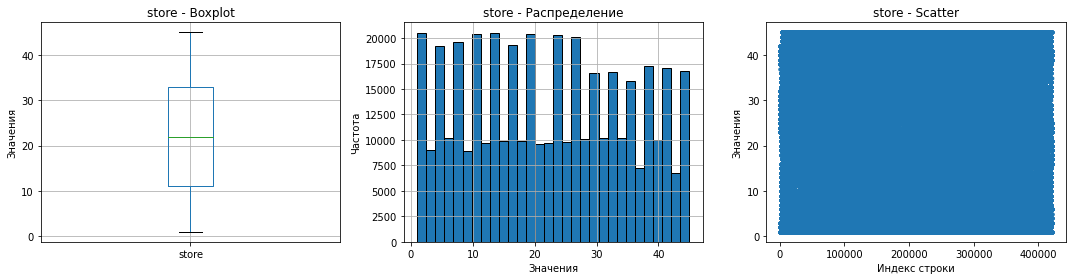

Колонка: dept --------------------------------------------------------
min      1.000000
max     99.000000
50%     37.000000
std     30.492054
mean    44.260317
Name: dept, dtype: float64


'Всего уникальных: 81'

'% уникальных: 0.02'

'Уникальные значения:'

'Уникальные значения (по убыванию частоты):'

'{1: 6435, 13: 6435, 2: 6435, 46: 6435, 67: 6435, 79: 6435, 21: 6435, 81: 6435, 82: 6435, 90: 6435}'

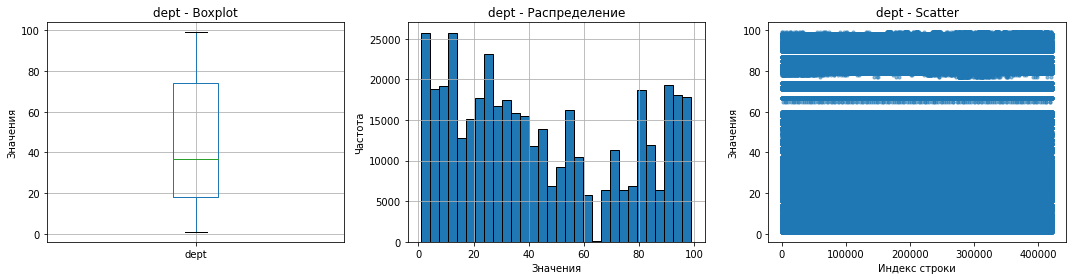

Высоко-кардиальная колонка: weekly_sales --------------------------------------------------------


'Всего уникальных: 359464'

'% уникальных: 85.27'

min      -4988.940000
max     693099.360000
50%       7612.030000
std      22711.183519
mean     15981.258123
Name: weekly_sales, dtype: float64


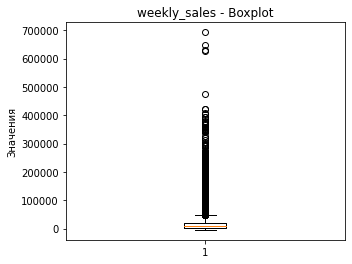

'Уникальные значения:'

'Первые 20 уникальных (убыв. частоты):'

'Первые 20 уникальных по убыв. частоты:'

'{10.0: 353, 5.0: 289, 20.0: 232, 15.0: 215, 12.0: 175, 1.0: 169, 10.47: 167, 11.97: 154, 2.0: 148, 7.0: 146, 3.0: 141, 30.0: 140, 25.0: 135, 5.88: 134, 40.0: 127, 8.0: 119, 88.0: 118, 45.0: 110, 4.0: 109, 50.0: 107}'

Колонка: is_holiday --------------------------------------------------------


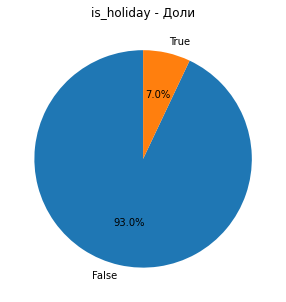

In [14]:
mydf_features_analysis(df_sales, num = 1, cat = 0)

**Анализ:**
* 'store': 1-45 дарксторов, все верно
* 'dept': номера отделов 1-99, все верно. Представлены 81
* 'weekly_sales': есть отрицательные, макс 693099
* 'is_holiday': праздников существенно меньше, все верно

**Выводы:**
* Правим отрицательные в weekly_sales

#### sales - EDA категорийных колонок

Категориальные признаки: []
Нет категориальных признаков для визуализации
Высоко-кардиальные признаки: ['date']
Высоко-кардиальная колонка: date --------------------------------------------------------


'Всего уникальных: 143'

'% уникальных: 0.03'

'Мин-Макс:'

Мин:2023-02-05 Макс: 2025-10-26


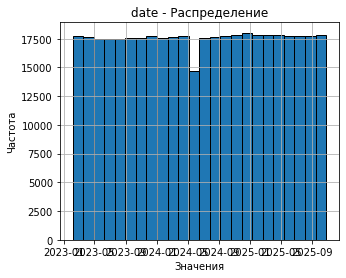

'Первые 20 уникальных по убыв. частоты:'

'{datetime.date(2024, 12, 22): 3027, datetime.date(2024, 11, 24): 3021, datetime.date(2024, 12, 15): 3013, datetime.date(2024, 12, 8): 3010, datetime.date(2025, 2, 16): 3007, datetime.date(2024, 12, 29): 3003, datetime.date(2025, 2, 9): 3001, datetime.date(2024, 12, 1): 2994, datetime.date(2025, 3, 2): 2990, datetime.date(2025, 10, 12): 2990, datetime.date(2025, 4, 6): 2983, datetime.date(2025, 4, 13): 2977, datetime.date(2023, 2, 19): 2977, datetime.date(2025, 2, 2): 2977, datetime.date(2025, 10, 5): 2976, datetime.date(2025, 4, 20): 2975, datetime.date(2025, 3, 9): 2974, datetime.date(2024, 5, 5): 2974, datetime.date(2025, 5, 11): 2973, datetime.date(2025, 1, 5): 2973}'

In [15]:
mydf_features_analysis(df_sales, num = 0, cat = 1)

**Анализ:**
* 'date': Мин:2023-02-05 Макс: 2025-10-26. 

**Выводы:**
* 'date': Период согласно ТЗ, все верно.

### stores - EDA

In [16]:
mydf_show_info(df_stores)

Обзор датасета:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   store   45 non-null     int64 
 1   type    45 non-null     object
 2   size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB

Первые строки:



,store,type,size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


Пропуски:


,,,null,NA,NaN,na,n/a,nan,none,NaN(isna)
store,0,0,0,0,0,0,0,0,0,0
type,0,0,0,0,0,0,0,0,0,0
size,0,0,0,0,0,0,0,0,0,0


Дубликаты строк: 0


**Анализ:**

* Полных дубликатов строк — 0

* Данные уже нормализованы, дополнительная дедупликация не требуется

* Пропусков нет

#### stores - EDA числовых колонок

Числовые признаки: ['store', 'size']
Булевые признаки: []
Высоко-кардиальные признаки: []
Колонка: store --------------------------------------------------------
min      1.000000
max     45.000000
50%     23.000000
std     13.133926
mean    23.000000
Name: store, dtype: float64


'Всего уникальных: 45'

'% уникальных: 100.0'

'Уникальные значения:'

'Уникальные значения (по убыванию частоты):'

'{1: 1, 24: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1}'

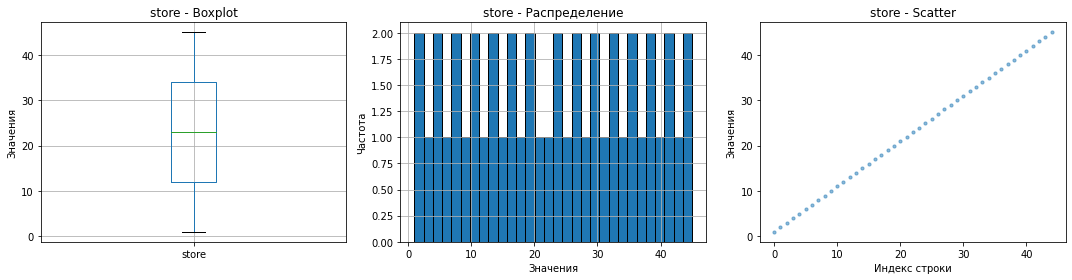

Колонка: size --------------------------------------------------------
min      34875.000000
max     219622.000000
50%     126512.000000
std      63825.271991
mean    130287.600000
Name: size, dtype: float64


'Всего уникальных: 40'

'% уникальных: 88.89'

'Уникальные значения:'

'Уникальные значения (по убыванию частоты):'

'{39910: 3, 39690: 3, 203819: 2, 112238: 1, 114533: 1, 219622: 1, 205863: 1, 41062: 1, 42988: 1, 57197: 1}'

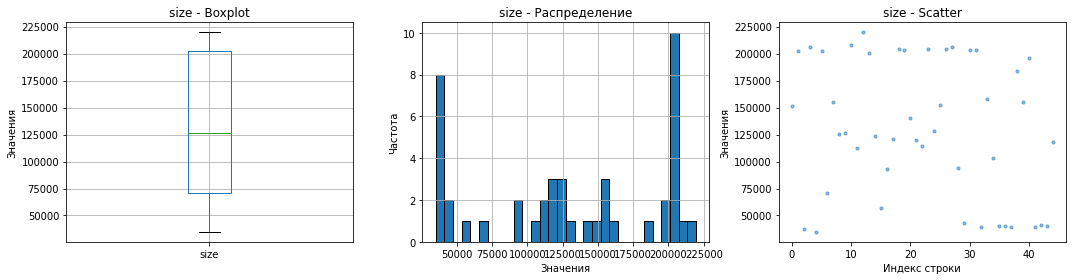

In [17]:
mydf_features_analysis(df_stores, num = 1, cat = 0)

**Анализ:**
* 'store': 1-45 дарксторов, все верно
* 'size': объем даркстора 34875-219622, превалируют два объема - около 40000 и около 200000

**Выводы:**
* 'size': мин порог чуть меньше заявленного не критично

#### stores - EDA категорийных колонок

Категориальные признаки: ['type']
Высоко-кардиальные признаки: []
Колонка: type --------------------------------------------------------


'Всего уникальных: 3'

'% уникальных: 6.67'

'Уникальные значения:'

'Уникальные значения (по убыванию частоты):'

"{'A': 22, 'B': 17, 'C': 6}"

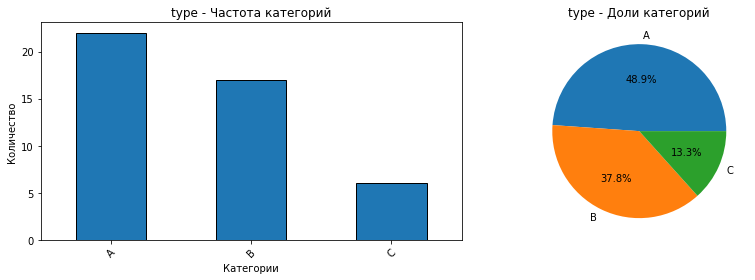

In [18]:
mydf_features_analysis(df_stores, num = 0, cat = 1)

**Анализ:**
* 'type':  Около 50% - А, 38% - В и 13% - С

**Выводы:**
* Крупные дарксторища превалируют, что подтверждается объемами, их основной объем около 200к
* Средние дарксторята размазаны по объемной сетке от 50к-200к объема
* Маленькие дарксторчики в основном около 40к ед объема

### features - EDA

In [19]:
mydf_show_info(df_features)

Обзор датасета:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   store         421570 non-null  int64  
 1   dept          421570 non-null  int64  
 2   date          421570 non-null  object 
 3   temperature   421570 non-null  float64
 4   fuel_price    421570 non-null  float64
 5   factor1       421570 non-null  float64
 6   factor2       111248 non-null  float64
 7   factor3       137091 non-null  float64
 8   factor4       134967 non-null  float64
 9   factor5       151432 non-null  float64
 10  cpi           421570 non-null  float64
 11  unemployment  421570 non-null  float64
dtypes: float64(9), int64(2), object(1)
memory usage: 38.6+ MB

Первые строки:



,store,dept,date,temperature,fuel_price,factor1,factor2,factor3,factor4,factor5,cpi,unemployment
0,1,1,2023-02-05,42.31,2.572,7028.8,NaN,NaN,NaN,NaN,211.096358,8.106
1,29,5,2023-02-05,24.36,2.788,7028.8,NaN,NaN,NaN,NaN,131.527903,10.064
2,29,6,2023-02-05,24.36,2.788,7028.8,NaN,NaN,NaN,NaN,131.527903,10.064
3,29,7,2023-02-05,24.36,2.788,7028.8,NaN,NaN,NaN,NaN,131.527903,10.064
4,29,8,2023-02-05,24.36,2.788,7028.8,NaN,NaN,NaN,NaN,131.527903,10.064


Пропуски:


,,,null,NA,NaN,na,n/a,nan,none,NaN(isna)
store,0,0,0,0,0,0,0,0,0,0
dept,0,0,0,0,0,0,0,0,0,0
date,0,0,0,0,0,0,0,0,0,0
temperature,0,0,0,0,0,0,0,0,0,0
fuel_price,0,0,0,0,0,0,0,0,0,0
factor1,0,0,0,0,0,0,0,0,0,0
factor2,0,0,0,0,0,0,0,0,0,310322
factor3,0,0,0,0,0,0,0,0,0,284479
factor4,0,0,0,0,0,0,0,0,0,286603
factor5,0,0,0,0,0,0,0,0,0,270138


Дубликаты строк: 0


**Анализ:**

* Полных дубликатов строк — 0

* Данные уже нормализованы, дополнительная дедупликация не требуется

* **Пропусков много**, 1151542 строк в factor2-5 столбцах

#### features - EDA числовых колонок

Числовые признаки: ['store', 'dept']
Булевые признаки: []
Высоко-кардиальные признаки: ['temperature', 'fuel_price', 'factor1', 'factor2', 'factor3', 'factor4', 'factor5', 'cpi', 'unemployment']
Колонка: store --------------------------------------------------------
min      1.000000
max     45.000000
50%     22.000000
std     12.785297
mean    22.200546
Name: store, dtype: float64


'Всего уникальных: 45'

'% уникальных: 0.01'

'Уникальные значения:'

'Уникальные значения (по убыванию частоты):'

'{13: 10474, 10: 10315, 4: 10272, 1: 10244, 2: 10238, 24: 10228, 27: 10225, 34: 10224, 20: 10214, 6: 10211}'

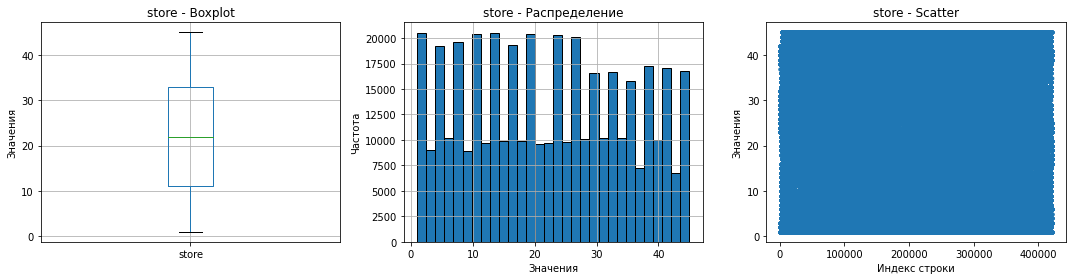

Колонка: dept --------------------------------------------------------
min      1.000000
max     99.000000
50%     37.000000
std     30.492054
mean    44.260317
Name: dept, dtype: float64


'Всего уникальных: 81'

'% уникальных: 0.02'

'Уникальные значения:'

'Уникальные значения (по убыванию частоты):'

'{1: 6435, 13: 6435, 2: 6435, 46: 6435, 67: 6435, 79: 6435, 21: 6435, 81: 6435, 82: 6435, 90: 6435}'

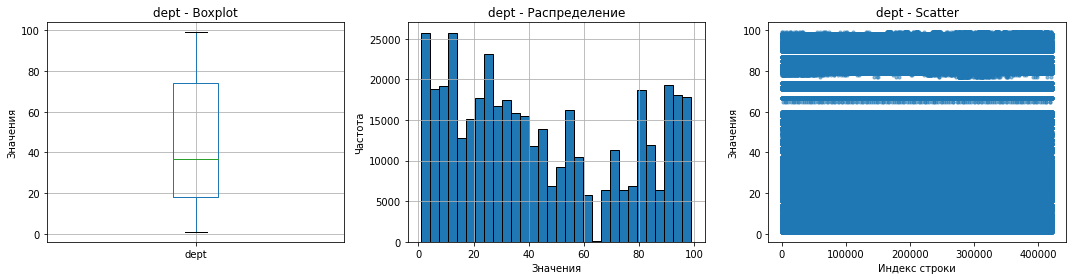

Высоко-кардиальная колонка: temperature --------------------------------------------------------


'Всего уникальных: 3528'

'% уникальных: 0.84'

min      -2.060000
max     100.140000
50%      62.090000
std      18.447931
mean     60.090059
Name: temperature, dtype: float64


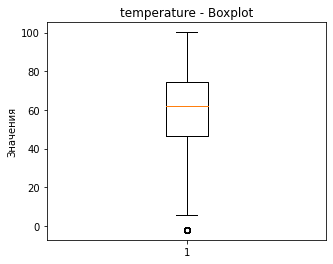

'Уникальные значения:'

'Первые 20 уникальных (убыв. частоты):'

'Первые 20 уникальных по убыв. частоты:'

'{50.43: 709, 67.87: 646, 72.62: 594, 76.67: 583, 70.28: 563, 76.03: 555, 50.56: 544, 64.05: 542, 64.21: 519, 50.81: 487, 62.62: 484, 44.42: 458, 52.27: 457, 70.19: 449, 78.47: 442, 49.96: 441, 40.65: 434, 58.97: 425, 70.87: 422, 69.31: 406}'

Высоко-кардиальная колонка: fuel_price --------------------------------------------------------


'Всего уникальных: 892'

'% уникальных: 0.21'

min     2.472000
max     4.468000
50%     3.452000
std     0.458515
mean    3.361027
Name: fuel_price, dtype: float64


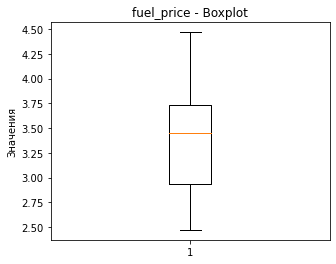

'Уникальные значения:'

'Первые 20 уникальных (убыв. частоты):'

'Первые 20 уникальных по убыв. частоты:'

'{3.638: 2548, 3.63: 2164, 2.771: 1917, 3.891: 1856, 3.594: 1796, 3.524: 1793, 3.523: 1792, 2.72: 1790, 3.666: 1778, 2.78: 1656, 3.129: 1618, 3.899: 1609, 3.842: 1587, 3.065: 1586, 3.112: 1558, 3.62: 1525, 3.452: 1522, 3.236: 1470, 2.728: 1435, 2.854: 1424}'

Высоко-кардиальная колонка: factor1 --------------------------------------------------------


'Всего уникальных: 2278'

'% уникальных: 0.54'

min       7028.800000
max     103184.980000
50%       7028.800000
std       9502.153632
mean     10337.221240
Name: factor1, dtype: float64


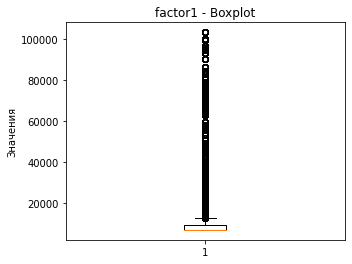

'Уникальные значения:'

'Первые 20 уникальных (убыв. частоты):'

'Первые 20 уникальных по убыв. частоты:'

'{7028.8: 270889, 7924.276403616934: 102, 7094.570694444443: 102, 7517.417371081901: 93, 8348.728449920509: 75, 8076.129625977558: 75, 16427.83: 75, 12658.02: 75, 8467.46: 75, 16384.510193838705: 74, 51834.62150871231: 74, 47514.54841749172: 74, 9260.90414038657: 74, 14581.74382123496: 74, 12666.836512195121: 74, 65844.01480476258: 74, 9761.641351772498: 74, 8241.564100719424: 74, 30904.305709133998: 74, 7517.216440849343: 74}'

Высоко-кардиальная колонка: factor2 --------------------------------------------------------


'Всего уникальных: 1499'

'% уникальных: 0.36'

min       -265.760000
max     104519.540000
50%        192.000000
std       9475.357325
mean      3334.628621
Name: factor2, dtype: float64


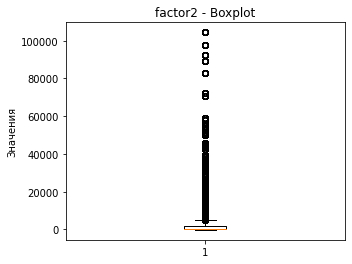

'Уникальные значения:'

'Первые 20 уникальных (убыв. частоты):'

'Первые 20 уникальных по убыв. частоты:'

'{1.91: 539, 3.0: 493, 0.5: 485, 1.5: 471, 4.0: 367, 6.0: 365, 7.64: 354, 3.82: 353, 5.73: 345, 19.0: 345, 16.0: 282, 9.0: 280, 7.0: 277, 56.0: 220, 12.0: 212, 0.18: 209, 0.03: 209, 0.0: 207, 20.0: 207, 6.47: 206}'

Высоко-кардиальная колонка: factor3 --------------------------------------------------------


'Всего уникальных: 1662'

'% уникальных: 0.39'

min        -29.100000
max     141630.610000
50%         24.600000
std       9623.078290
mean      1439.421384
Name: factor3, dtype: float64


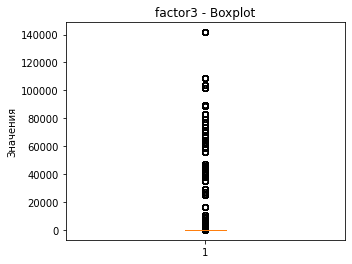

'Уникальные значения:'

'Первые 20 уникальных (убыв. частоты):'

'Первые 20 уникальных по убыв. частоты:'

'{3.0: 754, 6.0: 710, 2.0: 660, 1.0: 611, 0.22: 487, 0.5: 463, 0.01: 444, 4.0: 439, 3.2: 379, 1.98: 363, 0.6: 353, 50.0: 345, 0.99: 344, 1.02: 330, 2.16: 325, 0.3: 322, 1.5: 319, 0.24: 313, 2.02: 299, 2.6: 282}'

Высоко-кардиальная колонка: factor4 --------------------------------------------------------


'Всего уникальных: 1944'

'% уникальных: 0.46'

min         0.220000
max     67474.850000
50%      1481.310000
std      6292.384031
mean     3383.168256
Name: factor4, dtype: float64


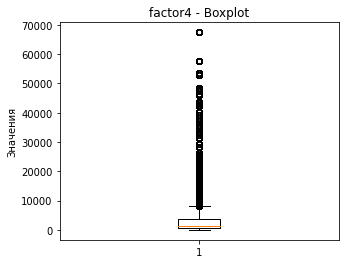

'Уникальные значения:'

'Первые 20 уникальных (убыв. частоты):'

'Первые 20 уникальных по убыв. частоты:'

'{9.0: 280, 4.0: 200, 2.0: 197, 3.0: 146, 47.0: 143, 67.72: 142, 657.56: 141, 17.0: 141, 1330.36: 140, 8.0: 140, 20.97: 137, 14.0: 137, 22.5: 135, 12.0: 134, 5.0: 115, 2.5: 110, 25.2: 102, 1778.83: 75, 239.78: 75, 18849.21: 75}'

Высоко-кардиальная колонка: factor5 --------------------------------------------------------


'Всего уникальных: 2293'

'% уникальных: 0.54'

min        135.160000
max     108519.280000
50%       3359.450000
std       5962.887455
mean      4628.975079
Name: factor5, dtype: float64


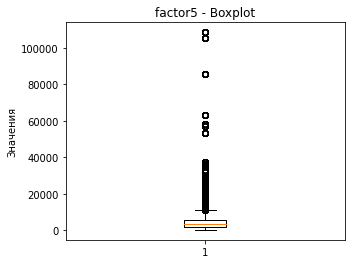

'Уникальные значения:'

'Первые 20 уникальных (убыв. частоты):'

'Первые 20 уникальных по убыв. частоты:'

'{2743.18: 136, 1064.56: 120, 3567.03: 75, 20371.02: 75, 4180.29: 75, 9083.54: 75, 3557.67: 75, 2739.43: 74, 3242.44: 74, 4535.27: 74, 3839.19: 74, 9654.23: 74, 1773.53: 74, 6779.43: 74, 7479.12: 74, 1691.83: 74, 4464.45: 74, 31844.2: 74, 4225.77: 74, 3248.83: 74}'

Высоко-кардиальная колонка: cpi --------------------------------------------------------


'Всего уникальных: 2145'

'% уникальных: 0.51'

min     126.064000
max     227.232807
50%     182.318780
std      39.159276
mean    171.201947
Name: cpi, dtype: float64


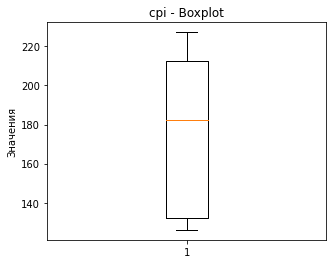

'Уникальные значения:'

'Первые 20 уникальных (убыв. частоты):'

'Первые 20 уникальных по убыв. частоты:'

'{129.8555333: 711, 131.1083333: 708, 129.8459667: 707, 130.3849032: 706, 131.0756667: 706, 130.6457931: 706, 130.683: 706, 130.7196333: 705, 130.4546207: 705, 129.8364: 704, 130.737871: 704, 131.1453333: 704, 129.9845484: 704, 130.244: 703, 131.043: 703, 130.7929: 703, 130.7909677: 703, 130.0710323: 703, 129.0444333: 702, 130.8896774: 701}'

Высоко-кардиальная колонка: unemployment --------------------------------------------------------


'Всего уникальных: 349'

'% уникальных: 0.08'

min      3.879000
max     14.313000
50%      7.866000
std      1.863296
mean     7.960289
Name: unemployment, dtype: float64


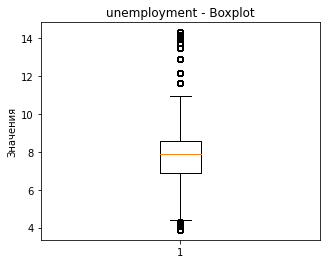

'Уникальные значения:'

'Первые 20 уникальных (убыв. частоты):'

'Первые 20 уникальных по убыв. частоты:'

'{8.099: 5152, 8.163: 3636, 7.852: 3614, 7.343: 3416, 7.057: 3414, 7.931: 3400, 7.441: 3397, 6.565: 3370, 8.2: 3361, 6.891: 3360, 8.028: 3105, 7.866: 2780, 8.684: 2725, 13.503: 2661, 14.313: 2636, 12.187: 2507, 11.627: 2502, 10.926: 2493, 12.89: 2491, 13.736: 2464}'

In [20]:
mydf_features_analysis(df_features, num = 1, cat = 0)

**Анализ:**
* 'store': 1-45 дарксторов, все представлены, все верно
* 'dept': номера отделов 1-99, все верно. Представлены 81
* 'temperature': -2 от 100. Что-то неладное! По цельсию такого не может быть, а вот по фаренгейту это -19...37.8, для периода февраль-октябрь звучит более логично
* 'fuel_price': от 2.47-4.25 ед.валюты за ед.объема, среднее и медианное не сильно разлетаются и находятся в районе 3.4 ед.вал.
* 'factor1': 7028 - 103185, 50% - 7028, неизвестный параметр, но 50% значений в миним. значении.
* 'factor2': -265 - 104519, 50% - 192, неизвестный параметр
* 'factor3': -29 - 141630, 50% - 25, неизвестный параметр
* 'factor4': 0 - 67475, 50% - 1481, неизвестный параметр
* 'factor5': 135 - 108519, 50% - 3360, неизвестный параметр
* 'cpi': 126 - 227, 50% - 182, ИПЦ неизвестно к какому периоду, но наверное к условно старту отсчета (кажется 2010 или 2017гг), иначе объяснить какой-нибудь месячный/декабрь к декабрю рост на 26%-127% невозможно. Принимаем за нормально.
* 'unemployment': 3.8 - 14, 50% - 7.96, выглядит приемлемо

**Выводы:**
* Исправить температуру в features/temperature

#### features - EDA категорийных колонок

Категориальные признаки: []
Нет категориальных признаков для визуализации
Высоко-кардиальные признаки: ['date']
Высоко-кардиальная колонка: date --------------------------------------------------------


'Всего уникальных: 143'

'% уникальных: 0.03'

'Мин-Макс:'

Мин:2023-02-05 Макс: 2025-10-26


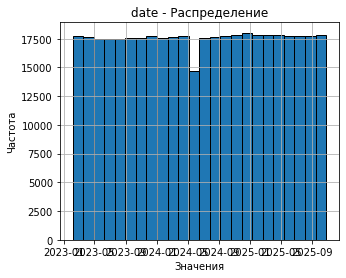

'Первые 20 уникальных по убыв. частоты:'

'{datetime.date(2024, 12, 22): 3027, datetime.date(2024, 11, 24): 3021, datetime.date(2024, 12, 15): 3013, datetime.date(2024, 12, 8): 3010, datetime.date(2025, 2, 16): 3007, datetime.date(2024, 12, 29): 3003, datetime.date(2025, 2, 9): 3001, datetime.date(2024, 12, 1): 2994, datetime.date(2025, 3, 2): 2990, datetime.date(2025, 10, 12): 2990, datetime.date(2025, 4, 6): 2983, datetime.date(2025, 4, 13): 2977, datetime.date(2023, 2, 19): 2977, datetime.date(2025, 2, 2): 2977, datetime.date(2025, 10, 5): 2976, datetime.date(2025, 4, 20): 2975, datetime.date(2025, 3, 9): 2974, datetime.date(2024, 5, 5): 2974, datetime.date(2025, 5, 11): 2973, datetime.date(2025, 1, 5): 2973}'

In [21]:
mydf_features_analysis(df_features, num = 0, cat = 1)

**Анализ:**
* 'date': Мин:2023-02-05 Макс: 2025-10-26

**Выводы:**
* даты соответствуют ожидаемым

## **Обработка датафреймов**

**Задача:** обработайте пропуски и дубликаты в каждой таблице.

Рекомендации по обработке пропусков:
- Для непрерывных переменных — заполнить средним значением.
- Для категориальных переменных — заполнить модой.
- Полные дубликаты строк — удалить.

Перед обработкой изучите структуру пропусков и их причины.

#### features/factor2-5 - Заполняем пропуски

In [22]:
factors_to_input = ['factor2','factor3','factor4','factor5']
for factor in factors_to_input:
        df_features[factor]=df_features[factor].fillna(df_features[factor].median())
                                                       
mydf_show_info(df_features)

Обзор датасета:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   store         421570 non-null  int64  
 1   dept          421570 non-null  int64  
 2   date          421570 non-null  object 
 3   temperature   421570 non-null  float64
 4   fuel_price    421570 non-null  float64
 5   factor1       421570 non-null  float64
 6   factor2       421570 non-null  float64
 7   factor3       421570 non-null  float64
 8   factor4       421570 non-null  float64
 9   factor5       421570 non-null  float64
 10  cpi           421570 non-null  float64
 11  unemployment  421570 non-null  float64
dtypes: float64(9), int64(2), object(1)
memory usage: 38.6+ MB

Первые строки:



,store,dept,date,temperature,fuel_price,factor1,factor2,factor3,factor4,factor5,cpi,unemployment
0,1,1,2023-02-05,42.31,2.572,7028.8,192.0,24.6,1481.31,3359.45,211.096358,8.106
1,29,5,2023-02-05,24.36,2.788,7028.8,192.0,24.6,1481.31,3359.45,131.527903,10.064
2,29,6,2023-02-05,24.36,2.788,7028.8,192.0,24.6,1481.31,3359.45,131.527903,10.064
3,29,7,2023-02-05,24.36,2.788,7028.8,192.0,24.6,1481.31,3359.45,131.527903,10.064
4,29,8,2023-02-05,24.36,2.788,7028.8,192.0,24.6,1481.31,3359.45,131.527903,10.064


Пропуски:


,,,null,NA,NaN,na,n/a,nan,none,NaN(isna)
store,0,0,0,0,0,0,0,0,0,0
dept,0,0,0,0,0,0,0,0,0,0
date,0,0,0,0,0,0,0,0,0,0
temperature,0,0,0,0,0,0,0,0,0,0
fuel_price,0,0,0,0,0,0,0,0,0,0
factor1,0,0,0,0,0,0,0,0,0,0
factor2,0,0,0,0,0,0,0,0,0,0
factor3,0,0,0,0,0,0,0,0,0,0
factor4,0,0,0,0,0,0,0,0,0,0
factor5,0,0,0,0,0,0,0,0,0,0


Дубликаты строк: 0


### Распределение продаж по месяцам и неделям

**Задача:** реализуйте функцию `create_temporal_features` для извлечения временных признаков из столбца `Date`.

Извлеките из даты:
- Месяц (`month`).
- Квартал (`quarter`).
- Год (`year`).

Эти признаки помогут модели уловить сезонные паттерны.

#### Создаем функцию create_temporal_features

In [23]:
# Функция для преобразования столбцов в даты
def create_temporal_features(my_df) -> pd.DataFrame:
    
    df = my_df.copy()
    
    # Преобразуем дату в datetime
    df['date'] = pd.to_datetime(df['date'])
    
    # Извлекаем временные признаки
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['week'] = df['date'].dt.isocalendar().week.astype('int64') #превращаем отвратительный UInt32 в нормальные числа
    df['quarter'] = df['date'].dt.quarter #квартал
    
    # Присваиваем сезонность
    df['season'] = df['month'].map({12: 'Зима', 1: 'Зима', 2: 'Зима',
                                     3: 'Весна', 4: 'Весна', 5: 'Весна',
                                     6: 'Лето', 7: 'Лето', 8: 'Лето',
                                     9: 'Осень', 10: 'Осень', 11: 'Осень'})
    return df

In [24]:
df_sales_timed = create_temporal_features(df_sales)
print(df_sales_timed.columns.to_list())
print('')
print('Уникальные значения в новых колонках:')
for col in ['year', 'month', 'week', 'quarter', 'season']:
    display(f"{col}: {df_sales_timed[col].unique().tolist()}") 

['store', 'dept', 'date', 'weekly_sales', 'is_holiday', 'year', 'month', 'week', 'quarter', 'season']

Уникальные значения в новых колонках:


'year: [2023, 2024, 2025]'

'month: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1]'

'week: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 1, 2, 3, 4]'

'quarter: [1, 2, 3, 4]'

"season: ['Зима', 'Весна', 'Лето', 'Осень']"

#### Визуализация распределения продаж

**Задача:** визуализируйте распределение продаж по времени (по месяцам и неделям).

Цель: выявить визуально наличие сезонности в данных. Обратите внимание:
- На периодические всплески (праздники, выходные).
- На общий тренд (рост и спад продаж).
- На аномальные периоды.

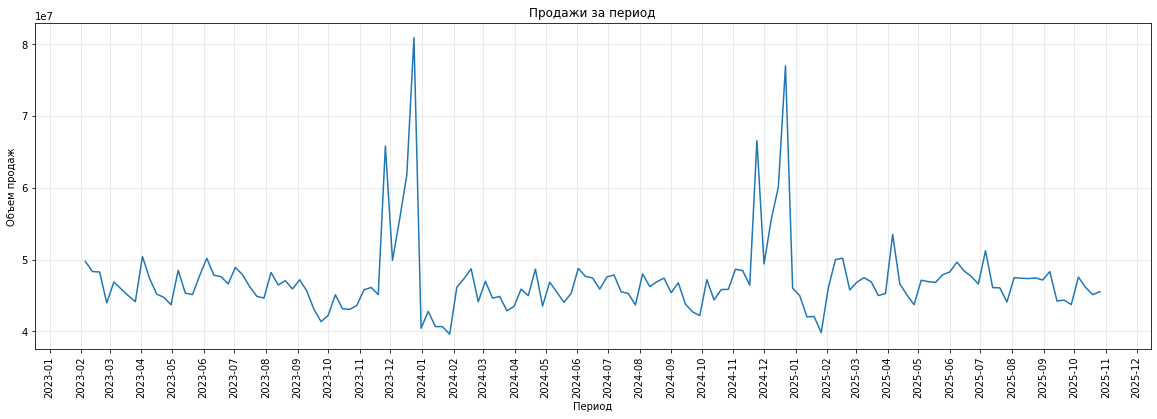

In [25]:
# строим визуализацю распределения продаж
fullperiod_sales = df_sales_timed.groupby(['date'])['weekly_sales'].sum()
plt.figure(figsize=(20,6))
plt.plot(fullperiod_sales.index, fullperiod_sales.values)
plt.title('Продажи за период')
plt.xlabel('Период')
plt.ylabel('Объем продаж')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.grid(True, alpha=0.3)
plt.xticks(rotation=90)
plt.show()

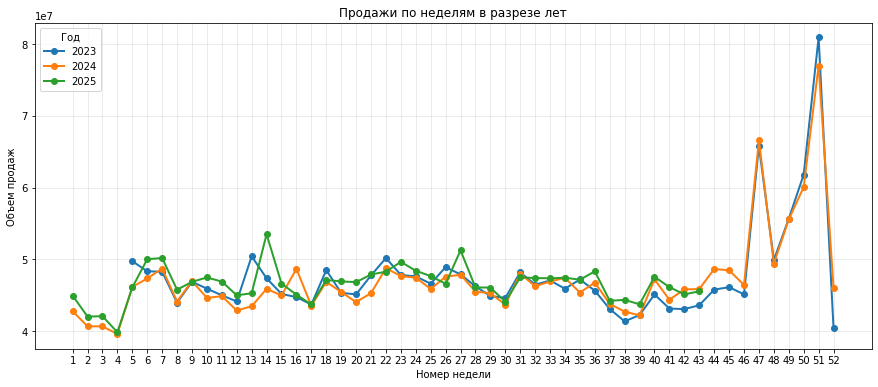

In [26]:
# Группируем по годам и неделям
weekly_by_year = df_sales_timed.groupby(['year', 'week'])['weekly_sales'].sum().reset_index()

plt.figure(figsize=(15, 6))
for year in weekly_by_year['year'].unique():
    data = weekly_by_year[weekly_by_year['year'] == year]
    plt.plot(data['week'], data['weekly_sales'], marker='o', label=str(year), linewidth=2)

plt.title('Продажи по неделям в разрезе лет')
plt.xlabel('Номер недели')
plt.ylabel('Объем продаж')
plt.legend(title='Год')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 53, 1))
plt.show()

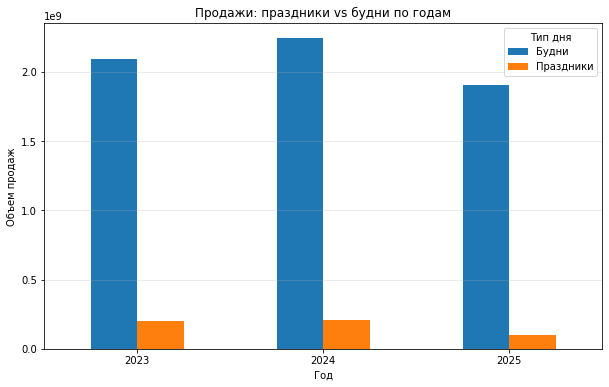

In [27]:
sales_by_year_holiday = df_sales_timed.groupby(['year', 'is_holiday'])['weekly_sales'].sum().unstack()

# Визуализация
sales_by_year_holiday.plot(kind='bar', figsize=(10, 6))
plt.title('Продажи: праздники vs будни по годам')
plt.xlabel('Год')
plt.ylabel('Объем продаж')
plt.legend(['Будни', 'Праздники'], title='Тип дня')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

**Анализ:**
* Всплески: 
    1. перед новогодними прадниками, в 11 и 12 месяце (те, кто заранее покупают подарки и прямо перед праздниками)
    2. Маленькие взлеты покупок в конце февраля и держится в марте (носки и цветошки, не иначе) и начале апреля (Начало дачного сезона?)
* Падения: Самая последняя старого года (52) (Все отдыхают, ничего не покупают?)

### **Объединяем таблицы**

**Задача:** объедините три таблицы в одну для дальнейшего анализа.

Используйте операции `merge()` для соединения таблиц по общим ключам.

In [28]:
display(df_sales_timed.head(1))

display(df_features.head(1))

display(df_stores.head(1))

,store,dept,date,weekly_sales,is_holiday,year,month,week,quarter,season
0,1,1,2023-02-05,24924.5,False,2023,2,5,1,Зима


,store,dept,date,temperature,fuel_price,factor1,factor2,factor3,factor4,factor5,cpi,unemployment
0,1,1,2023-02-05,42.31,2.572,7028.8,192.0,24.6,1481.31,3359.45,211.096358,8.106


,store,type,size
0,1,A,151315


In [29]:
# мерджим sales + features 
df_features['date'] = pd.to_datetime(df_features['date']) #преобразуем, иначе не сработает мердж
df_s_f_merged = pd.merge(df_sales_timed, df_features, how='left', on=['store', 'dept', 'date'])

# мерджим с stores
df_merged = pd.merge(df_s_f_merged, df_stores, how='left', on=['store'])

In [30]:
df_merged = df_merged[['store', 'dept', 'type', 'size', 'date', 
                       'year', 'season', 'quarter', 'month', 'week', 'is_holiday',
                       'factor1', 'factor2', 'factor3', 'factor4', 'factor5', 
                       'temperature', 'fuel_price','cpi', 'unemployment', 'weekly_sales']]

In [31]:
display(df_merged.sort_values(by=['store','dept','date']).head(10))

,store,dept,type,size,date,year,season,quarter,month,week,...,factor1,factor2,factor3,factor4,factor5,temperature,fuel_price,cpi,unemployment,weekly_sales
0,1,1,A,151315,2023-02-05,2023,Зима,1,2,5,...,7028.8,192.0,24.6,1481.31,3359.45,42.31,2.572,211.096358,8.106,24924.50
5747,1,1,A,151315,2023-02-12,2023,Зима,1,2,6,...,7028.8,192.0,24.6,1481.31,3359.45,38.51,2.548,211.242170,8.106,46039.49
6829,1,1,A,151315,2023-02-19,2023,Зима,1,2,7,...,7028.8,192.0,24.6,1481.31,3359.45,39.93,2.514,211.289143,8.106,41595.55
11698,1,1,A,151315,2023-02-26,2023,Зима,1,2,8,...,7028.8,192.0,24.6,1481.31,3359.45,46.63,2.561,211.319643,8.106,19403.54
12681,1,1,A,151315,2023-03-05,2023,Весна,1,3,9,...,7028.8,192.0,24.6,1481.31,3359.45,46.50,2.625,211.350143,8.106,21827.90
14978,1,1,A,151315,2023-03-12,2023,Весна,1,3,10,...,7028.8,192.0,24.6,1481.31,3359.45,57.79,2.667,211.380643,8.106,21043.39
20458,1,1,A,151315,2023-03-19,2023,Весна,1,3,11,...,7028.8,192.0,24.6,1481.31,3359.45,54.58,2.720,211.215635,8.106,22136.64
20906,1,1,A,151315,2023-03-26,2023,Весна,1,3,12,...,7028.8,192.0,24.6,1481.31,3359.45,51.45,2.732,211.018042,8.106,26229.21
26447,1,1,A,151315,2023-04-02,2023,Весна,2,4,13,...,7028.8,192.0,24.6,1481.31,3359.45,62.27,2.719,210.820450,7.808,57258.43
28687,1,1,A,151315,2023-04-09,2023,Весна,2,4,14,...,7028.8,192.0,24.6,1481.31,3359.45,65.86,2.770,210.622857,7.808,42960.91


### Оцениваем корреляцию ЦП с другими признаками

**Задача:** оцените корреляцию целевой переменной `Weekly_Sales` с другими признаками.

Используйте метод `.corr()` для расчёта корреляционной матрицы. Ответьте на вопросы:
- Какие признаки сильнее всего коррелируют с продажами?
- Есть ли сильно коррелирующие между собой признаки (мультиколлинеарность)?

**Хоть в задании и требуется corr, но он не учитывет нелинейные связи, поэтому я воспользуюсь фик матрицей. Надеюсь, это не критично.**

In [32]:
def build_phik(X, my_interval_cols):
    #сюда список числовых колонок, как непрерывные переменные, иначе бинит их
    my_phik = X.phik_matrix(interval_cols = my_interval_cols)

    # Создаем маску для верхнего треугольника
    mask = np.triu(np.ones_like(my_phik, dtype=bool), k=0)

    # Строим heatmap
    plt.figure(figsize=(15, 15))
    sns.heatmap(my_phik, 
                mask=mask, 
                annot=True, 
                fmt='.2f', 
                annot_kws={"size": 10},
                center=0, 
                square=True, 
                cmap='RdBu', 
                linewidths=0.5, 
                cbar_kws={"shrink": 0.6})

    plt.xticks(fontsize=12, rotation=45, ha='right')
    plt.yticks(fontsize=12, rotation=0)
    plt.title(f'Phik матрица корреляций ', fontsize=16)

    plt.tight_layout()
    plt.show()


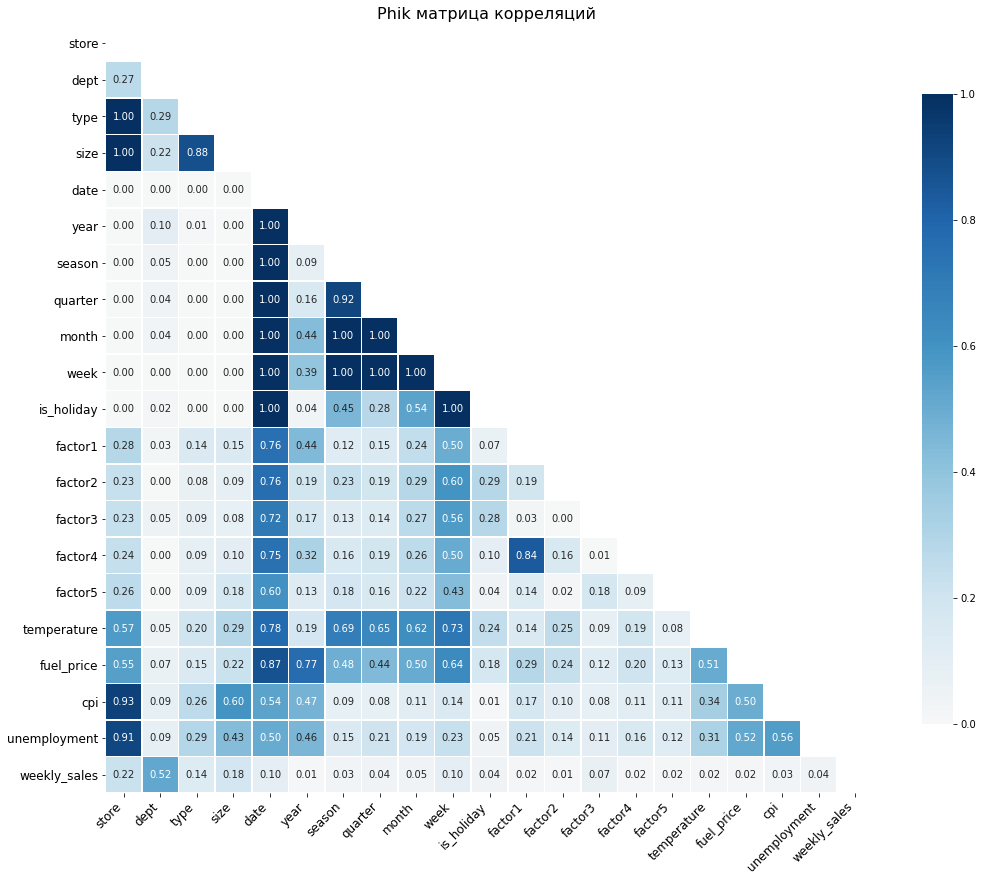

In [33]:
my_interval_cols = [
    'weekly_sales', 'size', 'temperature', 'fuel_price', 'cpi', 'unemployment',
    'factor1', 'factor2', 'factor3', 'factor4', 'factor5',
    
]

build_phik(df_merged, my_interval_cols) # строим фик

**Анализ:**
* 'weekly_sales' : ЦП, корреляция признаков:

    * 'store' : Прямая корреляция с type и size - логично, у каждого даркстора есть четко прописанный размер и тип.
    С ЦП присутствует слабая корреляция 0.22, поскольку у size корреляция 0.18, предположу что на объем продаж может не сильно влиять сам размер даркстора, сколько наполнение. Дорогие товары не нуждаются в больших объемах, а повседневные нужны в больших количествах. Однако, эти корреляции вторые по заметности после номера департамента.
     * 'dept' : номер отдела внутри даркстора достаточно серьезно коррелирует с недельными продажами. Вероятно, номер департамента это еще и тип департамента, с более ходовыми товарами. Также, коррелирует с типо-размером - логично, много отделов в маленьки дарксторах не бывает. Так же 
    * 'type' : почти прямая корреляция с size - логично, иначе типы не присваивали бы по размеру.
    * 'size': -//-


**Выводы:**
* Оставить для обучения модели только размер магазина и номер департамента, чтобы модель училась ловить общие связи, а не ориентироваться на номер магазина.

**Анализ:**
* 'weekly_sales' : ЦП, корреляция признаков:

    * 'date' : имеет слабую корреляцию с ЦП и коллинеарит со всеми датами-признаками (логично), сильно коллинеарит с рекламными факторами (не знаем что это, но наверное перед конкретными праздниками реклама более таргетированная)
    * 'year' : имеет около-нулевую с ЦП и коллинеарит со всеми датами-признаками (логично), имеет хорошую корреляцию с ценами на топливо, занятостью, ИПЦ - логично, это признаки последовательны и не меняются внезапно (чаще всего)
    * 'month' : -//-
    * 'week' : -//-
    * 'quarter' : -//-
    * 'season' : -//-
    * 'is_holiday' : -//-

    * 'temperature' : имеет около-нулевую с ЦП
    * 'fuel_price' : имеет около-нулевую с ЦП
    * 'factor1' : имеет около-нулевую с ЦП, видимо это дато-ориентированный признак, когда какую рекламу показывать
    * 'factor2' : имеет около-нулевую с ЦП
    * 'factor3' : имеет около-нулевую с ЦП
    * 'factor4' : имеет около-нулевую с ЦП
    * 'factor5' : имеет около-нулевую с ЦП
    * 'cpi' : имеет около-нулевую с ЦП
    * 'unemployment' : имеет около-нулевую с ЦП

**Выводы:**
* Кажется, среди всех временных признаков можно оставить week, как самую представительную. Она имеет достаточную дискретность, чтобы показать колебания и имеет хорошую цикличность.
* is_holiday 

### Обрабатываем аномалии в продажах.

#### Отрицательные продажи

**Задача:** обработайте аномалии в продажах.

Подсказка: могут ли продажи быть отрицательными? Решите, как с ними поступить.

Обоснуйте свой выбор.

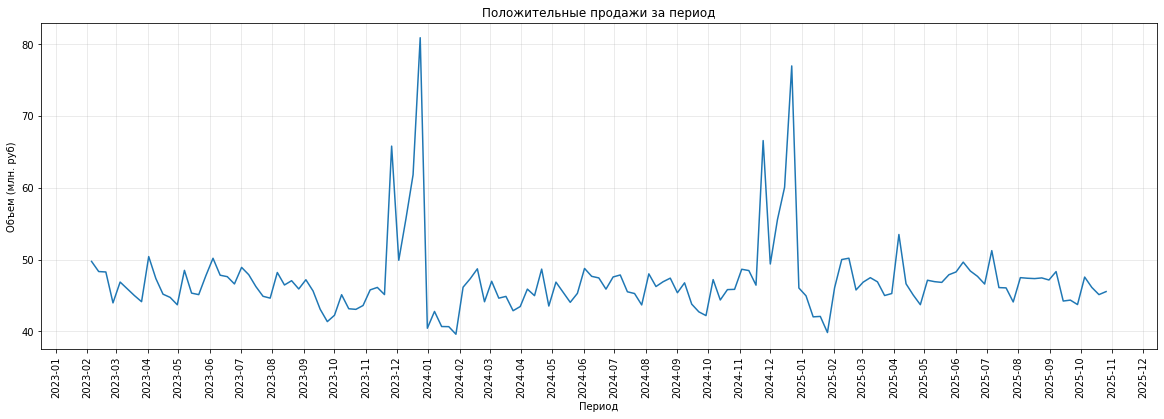

In [34]:
fullperiod_sales = df_merged[df_merged['weekly_sales'] >= 0].groupby('date')['weekly_sales'].sum() / (10**6)

plt.figure(figsize=(20, 6))
plt.plot(fullperiod_sales.index, fullperiod_sales.values)
plt.title('Положительные продажи за период')
plt.xlabel('Период')
plt.ylabel('Объем (млн. руб)')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.grid(True, alpha=0.3)
plt.xticks(rotation=90)
plt.show()

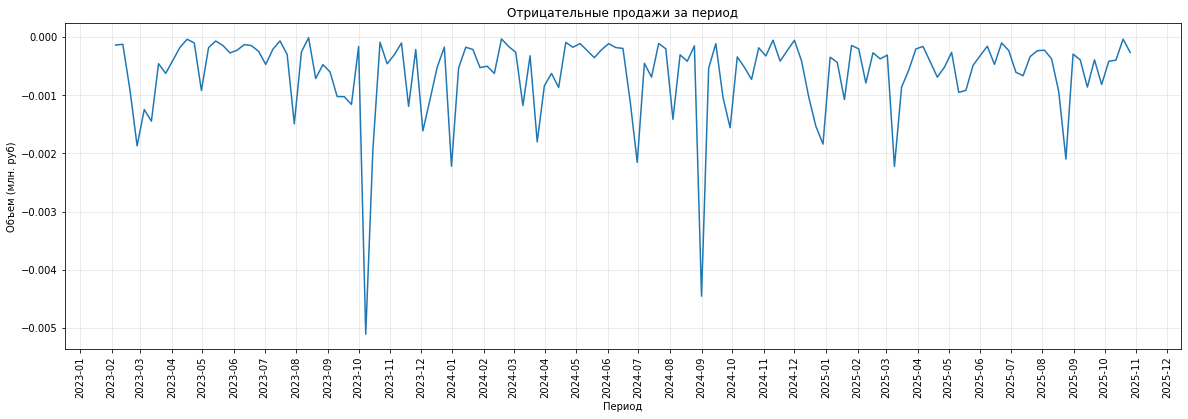

In [35]:
# строим визуализацю распределения ОТРИЦАТЛЕЬНЫХ продаж
fullperiod_sales = df_merged[df_merged['weekly_sales'] < 0].groupby('date')['weekly_sales'].sum() / (10**6)

plt.figure(figsize=(20,6))
plt.plot(fullperiod_sales.index, fullperiod_sales.values)
plt.title('Отрицательные продажи за период')
plt.xlabel('Период')
plt.ylabel('Объем (млн. руб)')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.grid(True, alpha=0.3)
plt.xticks(rotation=90)
plt.show()

**Анализ:**
* Наибольший объем отрицательных продаж присутствует в конце сентября-начале октября, меньшие объемы присутствуют в январе и марте. Но в 2025 этот тренд несколько изменился - январские и мартовкие объемы присутствуют, а вот сентябрьские сместились раньше и их объем значительно ниже. 

* Объемы отрицательных продаж в своей "худшей" точке достигают -5 тыс рублей, что является сотой долей процента от минимальных положительных продаж - влияние на обучение модели незначительное.

**Выводы:**
* Масштаб незначителен — -5к рублей при положительных продажах от 40 млн рублей составляет 0.0125%. 

* Нет устойчивого паттерна динамики возвратов хаотична и не имеет выраженной сезонности, которую модель могла бы выучить.

* В первую очередь прогноизруем продажи для планирования закупок. Возвраты в таком объёме не критичны для этого процесса, т.к. не повлияют на решение "здесь планируем чуть меньше закупки, чтобы скомпенсировать возвраты".

**Итого:**
* Удаляем строки с отрицательными продажами, не перегружаем модель. 

    В реальном бизнес-сценарии - я бы отдельно отслеживал динамику отрицательных продаж и пр достижении некоего "порога тревожности", например 0.5% продаж - переобучил бы модель.
    Вероятно, для такого переобучения было бы неплохо сделать отдельный признак "% возвратов от продаж" - ABS(neg.sales/pos.sales)

#### Положительные продажи

**Задача:** исследуйте аномально высокие продажи.

Найдите записи с очень высокими продажами (например, топ 0.01% или выше 99.99% квантиля). Попробуйте найти закономерности:
- В какое время года они происходят?
- Связаны ли они с праздниками?
- Какие типы дарксторов и отделы демонстрируют пиковые продажи?

In [36]:
threshold_09 = df_merged['weekly_sales'].quantile(0.99)
peak_sales = df_merged[df_merged['weekly_sales'] >= threshold_09]

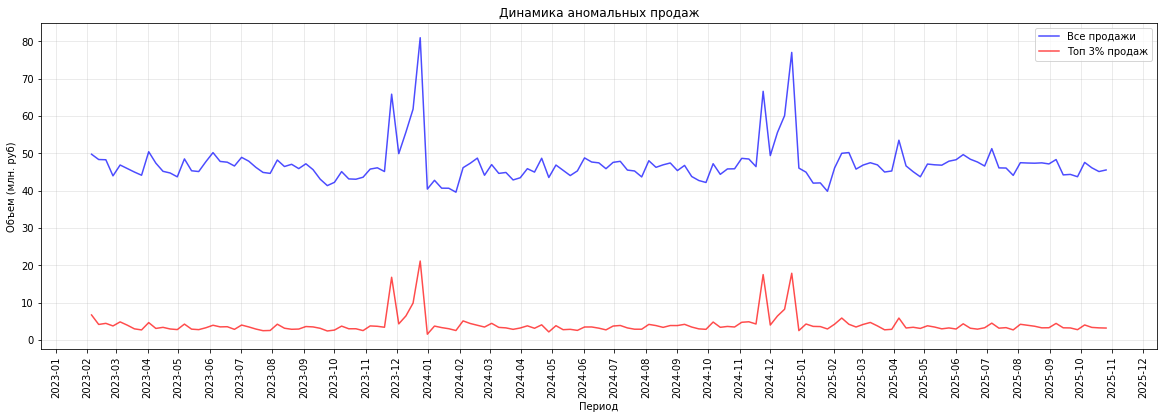

In [37]:
all_sales = df_merged.groupby('date')['weekly_sales'].sum() / (10**6)
anomaly_sales = peak_sales.groupby('date')['weekly_sales'].sum() / (10**6)

plt.figure(figsize=(20, 6))
plt.plot(all_sales.index, all_sales.values, label='Все продажи', color='blue', alpha=0.7)
plt.plot(anomaly_sales.index, anomaly_sales.values, label='Топ 3% продаж', color='red', alpha=0.7)
plt.title('Динамика аномальных продаж')
plt.xlabel('Период')
plt.ylabel('Объем (млн. руб)')
plt.legend()

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.grid(True, alpha=0.3)
plt.xticks(rotation=90)
plt.show()

**Анализ:**
* Всплески: 
    1. перед новогодними прадниками, в 11 и 12 месяце (те, кто заранее покупают подарки и прямо перед праздниками)
    2. Маленькие взлеты покупок в конце февраля и держится в марте (носки и цветошки, не иначе) и начале апреля (Начало дачного сезона?)

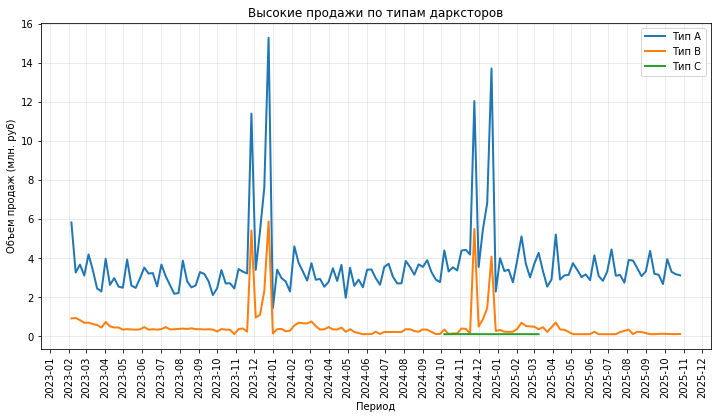

In [38]:
plt.figure(figsize=(12, 6))
for store_type in peak_sales['type'].unique():
    data = peak_sales[peak_sales['type'] == store_type].groupby('date')['weekly_sales'].sum() / (10**6)
    plt.plot(data.index, data.values, label=f'Тип {store_type}', linewidth=2)

plt.title('Высокие продажи по типам дарксторов')
plt.xlabel('Период')
plt.ylabel('Объем продаж (млн. руб)')
plt.legend()
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.grid(True, alpha=0.3)
plt.xticks(rotation=90)
plt.show()

**Анализ:**
* Пиковые продажи демонстрируют дарксторы типов А и В - крупные и средние, тип С практически не имеет аномальных продаж.

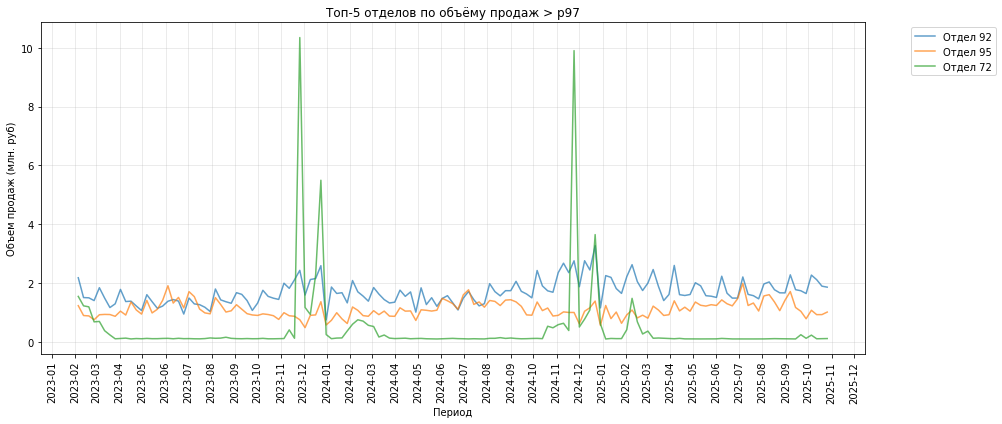

In [39]:
top_depts_by_sum = peak_sales.groupby('dept')['weekly_sales'].sum().sort_values(ascending=False).head(3).index

plt.figure(figsize=(14, 6))
for dept in top_depts_by_sum:
    data = peak_sales[peak_sales['dept'] == dept].groupby('date')['weekly_sales'].sum() / (10**6)
    plt.plot(data.index, data.values, label=f'Отдел {dept}', linewidth=1.5, alpha=0.7)

plt.title('Топ-5 отделов по объёму продаж > p97')
plt.xlabel('Период')
plt.ylabel('Объем продаж (млн. руб)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.grid(True, alpha=0.3)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Анализ:**
* Пиковые продажи демонстрируют отделы:
    * 72 - минимальные объемы продаж посреди года, но зато самые "выстреливающие" продажи в НГ праздники, вероятно - узкоспециализированный отдел с "праздничным" наполнением
    * 92 - стабильные "пиковые продажи" посреди года, но без выстреливающих аномалий в праздники, тем не менее, в праздники отмечается рост продаж этого отдела. Вероятно - собирает дорогие, пользующиеся стабильным спросом товары, но пользующиеся популярностью в праздники. Я бы предположил, что это электроника/бытовая техника
    * 95 - продажи сезонные, но зимние продажи ниже и не приходятся на НГ праздники. Рост продаж - лето. Предположительно - дачно/садовое и/или туристическое наполнение.

### **Шаг 2. Предобработка признаков и feature engineering**

#### weekly_sales - Заполняем пропуски

In [40]:
mydf_show_info(df_merged)

Обзор датасета:

<class 'pandas.core.frame.DataFrame'>
Int64Index: 421570 entries, 0 to 421569
Data columns (total 21 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   store         421570 non-null  int64         
 1   dept          421570 non-null  int64         
 2   type          421570 non-null  object        
 3   size          421570 non-null  int64         
 4   date          421570 non-null  datetime64[ns]
 5   year          421570 non-null  int64         
 6   season        421570 non-null  object        
 7   quarter       421570 non-null  int64         
 8   month         421570 non-null  int64         
 9   week          421570 non-null  int64         
 10  is_holiday    421570 non-null  bool          
 11  factor1       421570 non-null  float64       
 12  factor2       421570 non-null  float64       
 13  factor3       421570 non-null  float64       
 14  factor4       421570 non-null  float64       
 15  

,store,dept,type,size,date,year,season,quarter,month,week,...,factor1,factor2,factor3,factor4,factor5,temperature,fuel_price,cpi,unemployment,weekly_sales
0,1,1,A,151315,2023-02-05,2023,Зима,1,2,5,...,7028.8,192.0,24.6,1481.31,3359.45,42.31,2.572,211.096358,8.106,24924.50
1,29,5,B,93638,2023-02-05,2023,Зима,1,2,5,...,7028.8,192.0,24.6,1481.31,3359.45,24.36,2.788,131.527903,10.064,15552.08
2,29,6,B,93638,2023-02-05,2023,Зима,1,2,5,...,7028.8,192.0,24.6,1481.31,3359.45,24.36,2.788,131.527903,10.064,3200.22
3,29,7,B,93638,2023-02-05,2023,Зима,1,2,5,...,7028.8,192.0,24.6,1481.31,3359.45,24.36,2.788,131.527903,10.064,10820.05
4,29,8,B,93638,2023-02-05,2023,Зима,1,2,5,...,7028.8,192.0,24.6,1481.31,3359.45,24.36,2.788,131.527903,10.064,20055.64


Пропуски:


,,,null,NA,NaN,na,n/a,nan,none,NaN(isna)
store,0,0,0,0,0,0,0,0,0,0
dept,0,0,0,0,0,0,0,0,0,0
type,0,0,0,0,0,0,0,0,0,0
size,0,0,0,0,0,0,0,0,0,0
date,0,0,0,0,0,0,0,0,0,0
year,0,0,0,0,0,0,0,0,0,0
season,0,0,0,0,0,0,0,0,0,0
quarter,0,0,0,0,0,0,0,0,0,0
month,0,0,0,0,0,0,0,0,0,0
week,0,0,0,0,0,0,0,0,0,0


Дубликаты строк: 0


#### weekly_sales - Исправляем отрицательные

In [41]:
df_merged.loc[df_merged['weekly_sales'] < 0, 'weekly_sales'] = 0

In [42]:
df_merged['weekly_sales'].describe()

count    421570.000000
mean      15981.467250
std       22711.032446
min           0.000000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: weekly_sales, dtype: float64

#### temperature - Исправляем температуру 

Превращаем из F в C - чтобы было логично

In [43]:
df_merged['temperature'].describe()

count    421570.000000
mean         60.090059
std          18.447931
min          -2.060000
25%          46.680000
50%          62.090000
75%          74.280000
max         100.140000
Name: temperature, dtype: float64

In [44]:
#Превращаем из F в C - чтобы было логично
df_merged['temperature_c'] = (df_merged['temperature'] - 32) * 5/9

df_merged = df_merged.drop('temperature', axis = 1)

In [45]:
df_merged['temperature_c'].describe()

count    421570.000000
mean         15.605588
std          10.248851
min         -18.922222
25%           8.155556
50%          16.716667
75%          23.488889
max          37.855556
Name: temperature_c, dtype: float64

#### Создаем функцию create_avg_sales_feature

**Задача:** cоздайте агрегированные признаки в функции `create_avg_sales_feature` — средние продажи по комбинации «даркстор и отдел».

**Важно: Избегайте утечки данных!**

При создании агрегатов для каждой строки используйте только данные **до** этой даты:
- Для даты 2025-09-08 считайте среднее по данным с начала до 2025-09-07 включительно.
- Для даты 2025-09-15 считайте среднее по данным с начала до 2025-09-14 включительно.

Это критически важно, чтобы модель не использовала информацию из будущего!

In [46]:
def create_avg_sales_feature(my_df):
    df_featured = my_df.copy()
    
    # Сортируем данные для корректного окна расширения - сразу по магазину-департаменту-потом 
    df_featured = df_featured.sort_values(['store', 'dept', 'date'])
    
    # Вычисляем скользящее среднее по историческим данным
    df_featured['avg_sales_before'] = (
        df_featured
        .groupby(['store', 'dept'])['weekly_sales']
        .transform(lambda x: x.expanding().mean().shift(1)) #векторная операция для ускорения
        #убираем reset_index, т.к. значения признака присваиваются по позиции а не по исходному индексу
    )
    
    return df_featured

In [47]:
df_featured_v1 = create_avg_sales_feature(df_merged)
display(df_featured_v1.head(3))

,store,dept,type,size,date,year,season,quarter,month,week,...,factor2,factor3,factor4,factor5,fuel_price,cpi,unemployment,weekly_sales,temperature_c,avg_sales_before
0,1,1,A,151315,2023-02-05,2023,Зима,1,2,5,...,192.0,24.6,1481.31,3359.45,2.572,211.096358,8.106,24924.50,5.727778,NaN
5747,1,1,A,151315,2023-02-12,2023,Зима,1,2,6,...,192.0,24.6,1481.31,3359.45,2.548,211.242170,8.106,46039.49,3.616667,24924.500
6829,1,1,A,151315,2023-02-19,2023,Зима,1,2,7,...,192.0,24.6,1481.31,3359.45,2.514,211.289143,8.106,41595.55,4.405556,35481.995


#### Создаем функцию create_lag_features

**Задача:** создайте лаговые признаки в функции `create_lag_features` — продажи 1, 2 и 4 недели назад.

Лаговые признаки позволяют модели учитывать историю продаж:
- `sales_1week_ago` — продажи неделю назад.
- `sales_2week_ago` — продажи 2 недели назад.
- `sales_4week_ago` — продажи 4 недели назад.

Это одни из самых важных признаков для прогнозирования временных рядов!

In [48]:
def create_lag_features(my_df):
    df_sales_weeks_ago = my_df.copy()
    df_sorted = df_sales_weeks_ago.sort_values('date')
    
    df_sales_weeks_ago['sales_1week_ago'] = (
        df_sorted.groupby(['store', 'dept'])['weekly_sales']
        .shift(1) #ПРОШЛАЯ неделя
        .reset_index(drop=True)
    )
    
    df_sales_weeks_ago['sales_2week_ago'] = (
        df_sorted.groupby(['store', 'dept'])['weekly_sales']
        .shift(2) #ПОЗАПРОШЛАЯ НЕДЕЛЯ
        .reset_index(drop=True)
    )
    
    df_sales_weeks_ago['sales_4week_ago'] = (
        df_sorted.groupby(['store', 'dept'])['weekly_sales']
        .shift(4) #ЧЕТЫРЕ недели назад
        .reset_index(drop=True)
    )
    
    return df_sales_weeks_ago

In [49]:
df_featured_v2 = create_lag_features(df_featured_v1)
display(df_featured_v2)

,store,dept,type,size,date,year,season,quarter,month,week,...,factor5,fuel_price,cpi,unemployment,weekly_sales,temperature_c,avg_sales_before,sales_1week_ago,sales_2week_ago,sales_4week_ago
0,1,1,A,151315,2023-02-05,2023,Зима,1,2,5,...,3359.45,2.572,211.096358,8.106,24924.50,5.727778,NaN,NaN,NaN,NaN
5747,1,1,A,151315,2023-02-12,2023,Зима,1,2,6,...,3359.45,2.548,211.242170,8.106,46039.49,3.616667,24924.500000,24924.50,NaN,NaN
6829,1,1,A,151315,2023-02-19,2023,Зима,1,2,7,...,3359.45,2.514,211.289143,8.106,41595.55,4.405556,35481.995000,46039.49,24924.50,NaN
11698,1,1,A,151315,2023-02-26,2023,Зима,1,2,8,...,3359.45,2.561,211.319643,8.106,19403.54,8.127778,37519.846667,41595.55,46039.49,NaN
12681,1,1,A,151315,2023-03-05,2023,Весна,1,3,9,...,3359.45,2.625,211.350143,8.106,21827.90,8.055556,32990.770000,19403.54,41595.55,24924.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409117,45,98,B,118221,2025-09-28,2025,Осень,3,9,39,...,3288.25,3.997,192.013558,8.684,508.37,18.266667,551.792077,467.30,605.96,346.04
410297,45,98,B,118221,2025-10-05,2025,Осень,4,10,40,...,2340.01,3.985,192.170412,8.667,628.10,18.272222,551.460611,508.37,467.30,352.44
412702,45,98,B,118221,2025-10-12,2025,Осень,4,10,41,...,3990.54,4.000,192.327265,8.667,1061.02,12.483333,552.041212,628.10,508.37,605.96
417292,45,98,B,118221,2025-10-19,2025,Осень,4,10,42,...,1537.49,3.969,192.330854,8.667,760.01,13.594444,555.868120,1061.02,628.10,467.30


#### Создаем функцию create_rolling_features

**Задача:** cоздайте признаки скользящего среднего продаж за последние 2 и 4 недели в функции `create_rolling_features`.

Скользящее среднее сглаживает колебания и показывает общий тренд:
- `mean_sales_2week` — среднее продаж за последние 2 недели.
- `mean_sales_4week` — среднее продаж за последние 4 недели.

Эти признаки помогают уловить краткосрочные и среднесрочные тренды.

In [50]:
def create_rolling_features(my_df):
    df_mean_sales = my_df.copy()
    df_sorted = df_mean_sales.sort_values('date')
    
    df_sorted['mean_sales_2week'] = (df_sorted.groupby(['store', 'dept'])['weekly_sales']
        .shift(1) #НЕ ВКЛЮЧАЕМ текущую неделю
        .rolling(2, min_periods = 2) #для первых недель nan
        .mean()
        .reset_index(drop=True)  # сбрасываем store, dept
    )
    
    df_sorted['mean_sales_4week'] = (df_sorted.groupby(['store', 'dept'])['weekly_sales']
    .shift(1) #НЕ ВКЛЮЧАЕМ текущую неделю
    .rolling(4, min_periods = 4) #для первых недель nan
    .mean()
    .reset_index(drop=True)  # сбрасываем store, dept
    )
    
    return df_sorted

In [51]:
df_featured_v3 = create_rolling_features(df_featured_v2)
display(df_featured_v3)

,store,dept,type,size,date,year,season,quarter,month,week,...,cpi,unemployment,weekly_sales,temperature_c,avg_sales_before,sales_1week_ago,sales_2week_ago,sales_4week_ago,mean_sales_2week,mean_sales_4week
0,1,1,A,151315,2023-02-05,2023,Зима,1,2,5,...,211.096358,8.106,24924.50,5.727778,NaN,NaN,NaN,NaN,NaN,NaN
1,29,5,B,93638,2023-02-05,2023,Зима,1,2,5,...,131.527903,10.064,15552.08,-4.244444,NaN,NaN,NaN,NaN,NaN,NaN
2,29,6,B,93638,2023-02-05,2023,Зима,1,2,5,...,131.527903,10.064,3200.22,-4.244444,NaN,NaN,NaN,NaN,NaN,NaN
3,29,7,B,93638,2023-02-05,2023,Зима,1,2,5,...,131.527903,10.064,10820.05,-4.244444,NaN,NaN,NaN,NaN,NaN,NaN
4,29,8,B,93638,2023-02-05,2023,Зима,1,2,5,...,131.527903,10.064,20055.64,-4.244444,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,40,87,A,155083,2025-10-26,2025,Осень,4,10,43,...,138.728161,4.145,24638.96,9.805556,20037.954085,21846.83,26597.31,24079.83,13948.225,22527.3375
421566,19,30,A,203819,2025-10-26,2025,Осень,4,10,43,...,138.728161,7.992,3740.12,13.605556,4697.604014,3534.42,3162.46,2969.24,12690.625,8185.4175
421567,19,31,A,203819,2025-10-26,2025,Осень,4,10,43,...,138.728161,7.992,3128.17,13.605556,3066.864225,2525.66,3220.85,2669.91,3030.040,8489.1325
421568,19,33,A,203819,2025-10-26,2025,Осень,4,10,43,...,138.728161,7.992,5740.14,13.605556,6209.706690,6039.32,5921.39,5381.32,4282.490,8486.5575


#### Удаляем строки с пропусками

**Задача:** удалите строки с пропусками.

После создания лаговых и агрегированных признаков неизбежно появятся пропуски (особенно для первых недель, где нет истории). Удалите такие строки с помощью `dropna()`.

In [52]:
print(f"Строк до удаления: {len(df_featured_v3)}")
print(f"Пропуски по колонкам:\n{df_featured_v3.isnull().sum()}")

df_clean = df_featured_v3.dropna()

print(f"Строк после удаления: {len(df_clean)}")
print(f"Удалено строк: {len(df_featured_v3) - len(df_clean)}")

Строк до удаления: 421570
Пропуски по колонкам:
store                   0
dept                    0
type                    0
size                    0
date                    0
year                    0
season                  0
quarter                 0
month                   0
week                    0
is_holiday              0
factor1                 0
factor2                 0
factor3                 0
factor4                 0
factor5                 0
fuel_price              0
cpi                     0
unemployment            0
weekly_sales            0
temperature_c           0
avg_sales_before     3331
sales_1week_ago      3331
sales_2week_ago      6625
sales_4week_ago     13134
mean_sales_2week     3708
mean_sales_4week     4459
dtype: int64
Строк после удаления: 407616
Удалено строк: 13954


### **Шаг 3. Мониторинг стабильности признаков**

#### Разделяем df на тренировочную и валидационную части

**Задача:** разделите данные на обучающую и валидационную выборки **по времени**.

Разделение:
- **Обучение**: февраль 2023 — август 2025.
- **Валидация**: сентябрь 2025 — октябрь 2025.

Такое разделение имитирует реальное применение модели: обучаем на прошлых данных, проверяем на будущих.

In [53]:
Xy_train = df_clean[df_clean['date']<'2025-08-31']

X_train = Xy_train.drop('weekly_sales', axis = 1)
y_train = Xy_train['weekly_sales']


Xy_val = df_clean[(df_clean['date']>='2025-09-01') & (df_clean['date'] < '2025-11-01')]
X_val = Xy_val.drop('weekly_sales', axis = 1)
y_val = Xy_val['weekly_sales']


display(X_train.tail(3))
display(y_train.tail(3))

display(X_val.tail(3))
display(y_val.tail(3))

,store,dept,type,size,date,year,season,quarter,month,week,...,fuel_price,cpi,unemployment,temperature_c,avg_sales_before,sales_1week_ago,sales_2week_ago,sales_4week_ago,mean_sales_2week,mean_sales_4week
394876,16,93,B,57197,2025-08-24,2025,Лето,3,8,34,...,3.558,198.098420,6.061,16.355556,1022.244681,996.46,986.27,741.25,4081.575,5615.8375
394877,17,2,B,93188,2025-08-24,2025,Лето,3,8,34,...,3.582,130.838161,5.936,20.494444,41880.010226,38654.58,38351.12,40409.69,19825.520,13041.1275
394878,41,80,A,196321,2025-08-24,2025,Лето,3,8,34,...,3.558,198.098420,6.432,20.594444,17327.955489,21166.76,21831.27,19832.27,29910.670,16996.1225


394876      914.59
394877    40536.10
394878    20825.40
Name: weekly_sales, dtype: float64

,store,dept,type,size,date,year,season,quarter,month,week,...,fuel_price,cpi,unemployment,temperature_c,avg_sales_before,sales_1week_ago,sales_2week_ago,sales_4week_ago,mean_sales_2week,mean_sales_4week
421567,19,31,A,203819,2025-10-26,2025,Осень,4,10,43,...,4.071,138.728161,7.992,13.605556,3066.864225,2525.66,3220.85,2669.91,3030.040,8489.1325
421568,19,33,A,203819,2025-10-26,2025,Осень,4,10,43,...,4.071,138.728161,7.992,13.605556,6209.706690,6039.32,5921.39,5381.32,4282.490,8486.5575
421569,45,98,B,118221,2025-10-26,2025,Осень,4,10,43,...,3.882,192.308899,8.667,14.916667,557.391567,760.01,1061.02,508.37,3399.665,3214.8525


421567    3128.17
421568    5740.14
421569    1076.80
Name: weekly_sales, dtype: float64

In [54]:
print("Размеры выборок:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")

print("\nПересечение дат (должно быть пусто):")
print(f"Максимальная дата train: {Xy_train['date'].max()}")
print(f"Минимальная дата val: {Xy_val['date'].min()}")

print("\nЦелевая переменная в val:")
print(y_val.describe())

Размеры выборок:
X_train: (380963, 26), y_train: (380963,)
X_val: (23695, 26), y_val: (23695,)

Пересечение дат (должно быть пусто):
Максимальная дата train: 2025-08-24 00:00:00
Минимальная дата val: 2025-09-07 00:00:00

Целевая переменная в val:
count     23695.000000
mean      15391.507529
std       21790.785356
min           0.000000
25%        2000.025000
50%        7271.970000
75%       19217.480000
max      192860.850000
Name: weekly_sales, dtype: float64


In [55]:
print("Последние 3 даты train:")
print(sorted(Xy_train['date'].unique())[-3:])

print("\nПервые 3 даты val:")
print(sorted(Xy_val['date'].unique())[:3])

Последние 3 даты train:
[numpy.datetime64('2025-08-10T00:00:00.000000000'), numpy.datetime64('2025-08-17T00:00:00.000000000'), numpy.datetime64('2025-08-24T00:00:00.000000000')]

Первые 3 даты val:
[numpy.datetime64('2025-09-07T00:00:00.000000000'), numpy.datetime64('2025-09-14T00:00:00.000000000'), numpy.datetime64('2025-09-21T00:00:00.000000000')]


**Анализ:**
* Разрыв между 24 августа и 7 сентября составляет 14 дней, это особенность исходных данных

#### Рассчитываем PSI для признаков

**Задача:** рассчитайте PSI для всех признаков.

PSI измеряет стабильность распределения признака между обучающей и валидационной выборками:
- **PSI < 0.1** — признак стабилен, можно использовать.
- **0.1 ≤ PSI < 0.2** — умеренный дрейф, требуется внимание.
- **PSI ≥ 0.2** — значительный дрейф, признак нестабилен.

In [56]:
#считаем PSI
def calculate_psi(expected, actual, bins=10):
    expected_percents, bins = pd.cut(expected, bins=bins, retbins=True, include_lowest=True)
    actual_percents = pd.cut(actual, bins=bins, include_lowest=True)
    
    expected_dist = expected_percents.value_counts(normalize=True).sort_index()
    actual_dist = actual_percents.value_counts(normalize=True).sort_index()
    
    psi = 0
    for bucket in expected_dist.index:
        e = expected_dist[bucket]
        a = actual_dist.get(bucket, 0)
        
        if a > 0 and e > 0:
            psi += (a - e) * np.log(a / e)
    
    return psi

#маркируем статусами результат
def get_psi_status(psi):
    if psi < 0.1:
        return 'признак стабилен, можно использовать.'
    elif psi < 0.2:
        return 'умеренный дрейф, требуется внимание.'
    else:
        return 'значительный дрейф, признак нестабилен.'

In [57]:
#отделяем числовые признаки
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

psi_results = []

for feature in numeric_features:
    psi_value = calculate_psi(X_train[feature], X_val[feature])
    psi_results.append({'feature': feature, 'PSI': psi_value, 'status': get_psi_status(psi_value)})

psi_df = pd.DataFrame(psi_results).sort_values('PSI', ascending=False)

print("Результаты PSI:")
print(psi_df.to_string(index=False))

Результаты PSI:
         feature      PSI                                  status
           month 1.702794 значительный дрейф, признак нестабилен.
            week 1.358325 значительный дрейф, признак нестабилен.
            year 0.980407 значительный дрейф, признак нестабилен.
      fuel_price 0.889722 значительный дрейф, признак нестабилен.
             cpi 0.438924 значительный дрейф, признак нестабилен.
         quarter 0.410607 значительный дрейф, признак нестабилен.
    unemployment 0.254667 значительный дрейф, признак нестабилен.
   temperature_c 0.202452 значительный дрейф, признак нестабилен.
         factor1 0.123578    умеренный дрейф, требуется внимание.
         factor5 0.040566   признак стабилен, можно использовать.
         factor4 0.005184   признак стабилен, можно использовать.
mean_sales_4week 0.001410   признак стабилен, можно использовать.
            dept 0.000813   признак стабилен, можно использовать.
mean_sales_2week 0.000748   признак стабилен, можно использо

#### Интерпретируем PSI

**Задача:** интерпретируйте результаты PSI.

Проанализируйте полученные значения PSI:
- Какие признаки стабильны?
- Для каких признаков наблюдается дрейф?

Визуализируйте распределения признаков с высоким PSI на обучении и валидации для лучшего понимания.

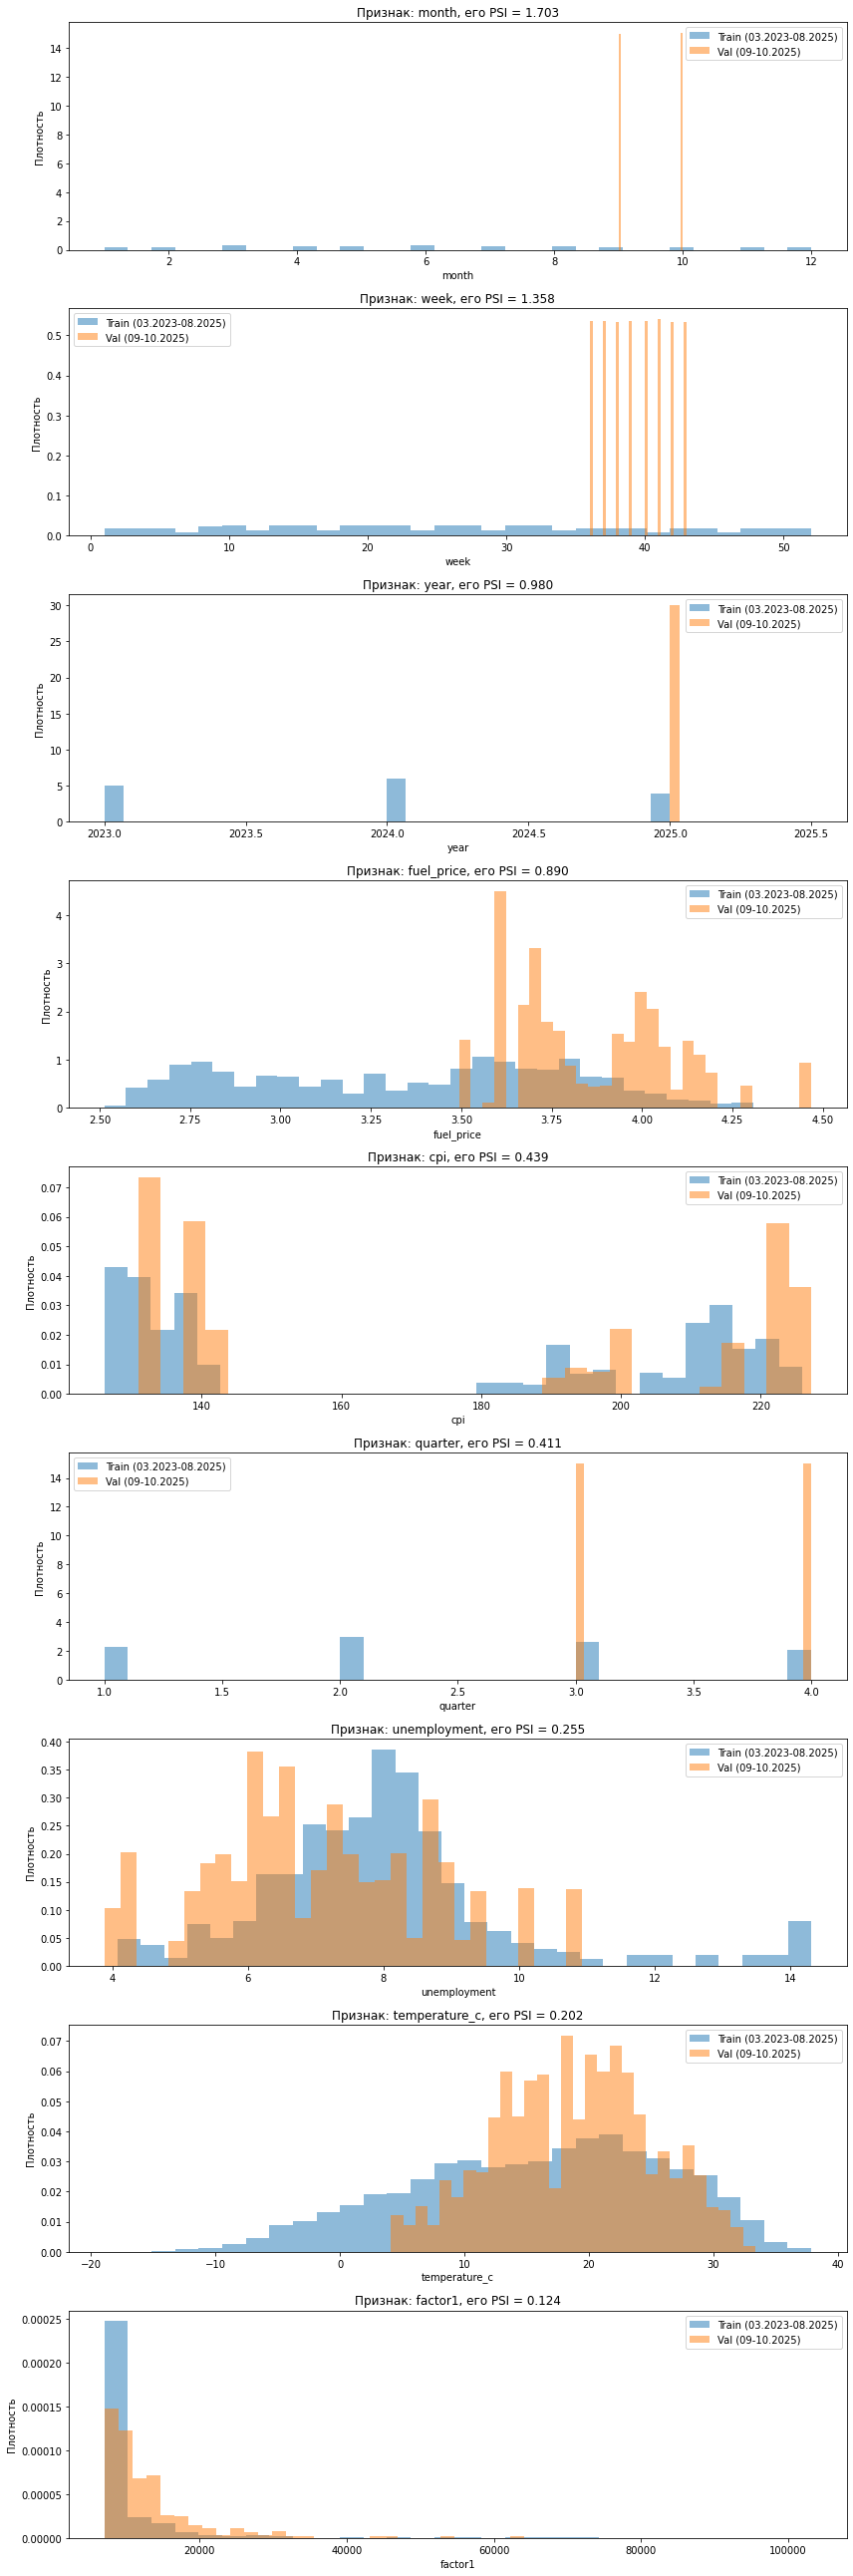

In [58]:
unstable_features = psi_df[psi_df['PSI'] >= 0.1]['feature'].tolist()

fig, axes = plt.subplots(len(unstable_features), 1, figsize=(12, 4*len(unstable_features)))
if len(unstable_features) == 1:
    axes = [axes]

for i, feature in enumerate(unstable_features):
    axes[i].hist(X_train[feature], bins=30, alpha=0.5, label='Train (03.2023-08.2025)', density=True)
    axes[i].hist(X_val[feature], bins=30, alpha=0.5, label='Val (09-10.2025)', density=True)
    axes[i].set_title(f'Признак: {feature}, его PSI = {psi_df[psi_df["feature"]==feature]["PSI"].values[0]:.3f}')
    axes[i].legend()
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Плотность')

plt.tight_layout()
plt.show()

**Анализ:**
* 'month': циклический признак, его распределение отличается из-за разницы в датах между выборками. Оставляем.
* 'week': циклический признак, его распределение отличается из-за разницы в датах между выборками. Оставляем.
* 'year': линейный тренд, экстраполировать нельзя. Удаляем.
* 'fuel_price': линейный тренд, экстраполировать нельзя. Удаляем.
* 'cpi': линейный тренд, экстраполировать нельзя. Удаляем.

    НО ВООБЩЕ - в реальной бизнес-задаче я бы подключил отдельно модель, которая прогноизрует ИПЦ, так как вообще-то это важный признак. Единственное, он не повлияет на прогноз объемов закупки, но мог бы косвенно показать возможные возвраты и т.п. связанное с покупательной способностью потребителей.
    Но, к сожалению, в нашем случае неизвестно как значения CPI получены - это год к году/к базовому значению или как-то еще, поэтому для текущей задачи точно удаляем.
    
    **ДОП: Не знаю существующих моделей по прогнозированию ИПЦ, в реальности сталкивался с тем, что в каждой организации (даже отделе внутри организации) считают прогнозы по ИПЦ на свой лад. Тут скорее про то, что ИПЦ отдельно _как-то_ прогнозировать и включать это в модель здесь, чтобы спрогнозировать динамику покупательной способности и возможное снижение/увеличение обемов покупок.**
    

* 'quarter': циклический признак, его распределение отличается из-за разницы в датах между выборками. Тем не менее, унас есть более дробные временные признаки - месяц и неделя. Поскольку мы прогнозируем каждую неделю, то нам такая большая дискретность вряд ли поможет и скорее может "сгладить" некие (праздничные) скачки, которые вообще-то хорошо бы угадать. Удаляем.
* 'unemployment': линейный тренд, экстраполировать нельзя. Удаляем.
* 'temperature': сезонный признак. PSI будет высоким, так как train охватывает все сезоны (зима-лето-осень), а val только кусочек осени 2025. Он может повлиять на продажи туристического/дачного ассортимента, не смотря на время года. оставляем.
* 'factor1': анонимизированный маркетинговый фактор. Т.к. PSI >= 0.2 — это реальный дрейф (изменилась стратегия промо?). Удаляем.

**Выводы:**
* Оставляем: month, week, temperature
* Удаляем: year, fuel_price, cpi, quarter, unemployemnt, factor1

#### Удаляем признаки с PSI ≥ 0.2.

**Задача:** удалите признаки с PSI ≥ 0.2.

Признаки с высоким PSI нестабильны и могут ухудшить качество модели в будущем. Удалите их из обучающей и валидационной выборок.

In [59]:
#Удаляем: year, fuel_price, cpi, quarter, unemployemnt, factor1

X_train = X_train.drop(columns=['date', 'store',  'year', 'fuel_price', 'cpi', 'quarter', 'unemployment', 'factor1'], axis = 1)
X_val =X_val.drop(columns=['date', 'store',  'year', 'fuel_price', 'cpi', 'quarter', 'unemployment', 'factor1'], axis = 1)

In [60]:
display(X_train.columns)
display(X_val.columns)
print(f'Различие в: {list(set(X_train.columns.to_list()) - set(X_val.columns.to_list()))}')

Index(['dept', 'type', 'size', 'season', 'month', 'week', 'is_holiday',
       'factor2', 'factor3', 'factor4', 'factor5', 'temperature_c',
       'avg_sales_before', 'sales_1week_ago', 'sales_2week_ago',
       'sales_4week_ago', 'mean_sales_2week', 'mean_sales_4week'],
      dtype='object')

Index(['dept', 'type', 'size', 'season', 'month', 'week', 'is_holiday',
       'factor2', 'factor3', 'factor4', 'factor5', 'temperature_c',
       'avg_sales_before', 'sales_1week_ago', 'sales_2week_ago',
       'sales_4week_ago', 'mean_sales_2week', 'mean_sales_4week'],
      dtype='object')

Различие в: []


### **Шаг 4. Обучение модели CatBoost**

#### Обучаем котобуст

**Задача:** обучите модель CatBoost.

Используйте **обучающую** выборку.

In [61]:
display(X_train.columns)

Index(['dept', 'type', 'size', 'season', 'month', 'week', 'is_holiday',
       'factor2', 'factor3', 'factor4', 'factor5', 'temperature_c',
       'avg_sales_before', 'sales_1week_ago', 'sales_2week_ago',
       'sales_4week_ago', 'mean_sales_2week', 'mean_sales_4week'],
      dtype='object')

In [62]:
display(df_plan)

,store,dept,date,is_holiday
0,1,1,2025-11-02,False
1,1,1,2025-11-09,False
2,1,1,2025-11-16,False
3,1,1,2025-11-23,True
4,1,1,2025-11-30,False
...,...,...,...,...
115059,45,98,2026-06-28,False
115060,45,98,2026-07-05,False
115061,45,98,2026-07-12,False
115062,45,98,2026-07-19,False


In [63]:
# категориальные признаки
cat_features = ['dept', 'type', 'is_holiday', 'season']

In [64]:
#определим optuna для подбора гиперпараметров

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 500, 700, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.04, 0.1),
        'depth': trial.suggest_int('depth', 4, 7),
        'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 5, 10)
    }
    
    model = CatBoostRegressor(
        **params,
        cat_features=cat_features,
        verbose=False,
        random_seed=RANDOM_STATE
    )
    
    scores = cross_val_score(
        model, X_train, y_train, 
        cv=5, 
        scoring='neg_mean_absolute_error', #пытаемся минимизировать физическую ошибку по деньгам (MAE)
        n_jobs=-1
    )
    
    return -scores.mean()

In [65]:
optuna = False #ОТКЛЮЧИЛИ optuna для экономии времени,т.к. уже провели и нашли лучшие гиперпараметры (указаны в следующем выводе)

if optuna:
    start_time = time.time()

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=10, show_progress_bar=True)

    end_time = time.time()

    print(f'Оптимизировали за: {(end_time - start_time)/60:.2f} минут')
    print(f'Лучшие параметры: {study.best_params}')
    print(f'Лучшая MAE: {study.best_value:.2f}')

In [66]:
start_time = time.time()

if optuna: #Если оптюна включена
    # Обучаем финальную модель на найденных выше в оптюне и переданных сюда автоматически параметрах
    model = CatBoostRegressor(
        **study.best_params,
        cat_features=cat_features,
        verbose=100,
        random_seed=RANDOM_STATE #42
    )
else:
    # Обучаем финальную модель на уже найденных лучших гиперпараметрах, указали их здесь вручную
    model = CatBoostRegressor(
        iterations = 700,
        learning_rate = 0.059,
        depth = 6,
        l2_leaf_reg = 7,
        cat_features=cat_features,
        verbose=100,
        random_seed=RANDOM_STATE #42
    )

model.fit(X_train, y_train)

end_time = time.time()
learning_time = end_time - start_time
print(f'Обучается за: {learning_time/60} минут')


0:	learn: 21604.2355736	total: 403ms	remaining: 4m 41s
100:	learn: 4875.0946781	total: 27.3s	remaining: 2m 41s
200:	learn: 4525.2650938	total: 53.7s	remaining: 2m 13s
300:	learn: 4309.8822785	total: 1m 20s	remaining: 1m 46s
400:	learn: 4150.1001513	total: 1m 45s	remaining: 1m 18s
500:	learn: 4017.9621764	total: 2m 10s	remaining: 51.9s
600:	learn: 3865.6016021	total: 2m 36s	remaining: 25.7s
699:	learn: 3730.4134336	total: 3m 1s	remaining: 0us
Обучается за: 3.0707855343818666 минут


#### Оцениваем котобуст

**Задача:** оцените качество модели на валидационной выборке.

Используйте метрики:
- **MAE**.
- **RMSE**.
- **R²**.

In [67]:
# предсказания на train val
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

# метрики на train
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# метрики на val
val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2 = r2_score(y_val, y_val_pred)

print("Обучающая выборка:")
print(f"MAE: {train_mae:.2f}")
print(f"RMSE: {train_rmse:.2f}")
print(f"R2: {train_r2:.4f}")

print("\nВалидационная выборка:")
print(f"MAE: {val_mae:.2f}")
print(f"RMSE: {val_rmse:.2f}")
print(f"R2: {val_r2:.4f}")

# проверка переобучения
print(f"\nРазница MAE (val - train): {val_mae - train_mae:.2f}")

Обучающая выборка:
MAE: 1603.75
RMSE: 3707.86
R2: 0.9735

Валидационная выборка:
MAE: 1364.61
RMSE: 2875.04
R2: 0.9826

Разница MAE (val - train): -239.14


**Анализ:**

* Качество прогноза

    * MAE = 1604 руб — средняя ошибка предсказания продаж

        При средних продажах 15 384 руб ошибка составляет 13% - кажется, что приемлемо. но не были указаны бизнес-требования, поэтому считаем, что справились =)
        

    * R2 = 0.97 — модель объясняет 97% продаж

* Стабильность

    * Разница MAE (val - train) = -239, метрики на новых данных лучше, чем на обучающих

    Разница небольшая - переобучение отсутствует

**Выводы:**

* Модель готова к развертыванию. Бизнес-требования выполнены.


#### Анализируем важность признаков

**Задача:** проанализируйте важность признаков.

Она показывает, какие признаки наиболее важны для модели:
- Проверьте, нет ли в топе признаков, которые могут приводить к утечке данных.
- Посмотрите, какие признаки действительно влияют на продажи.


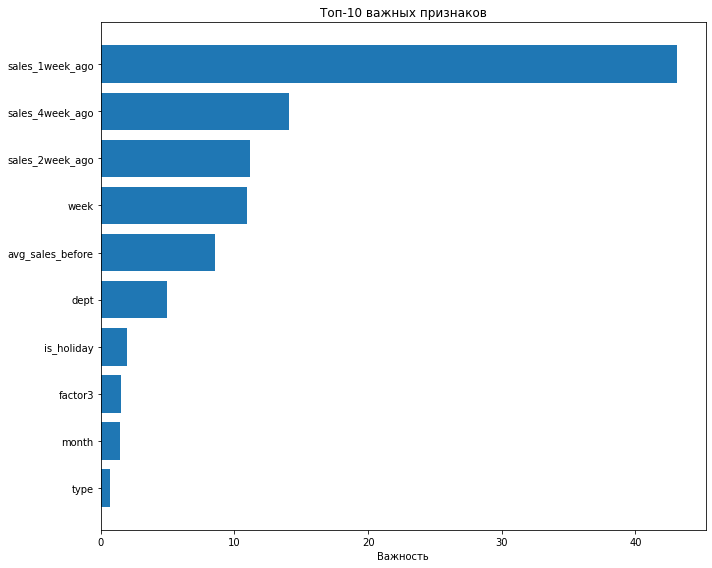

Топ-10 важных признаков:
         feature  importance
 sales_1week_ago   43.104439
 sales_4week_ago   14.092223
 sales_2week_ago   11.176515
            week   10.937731
avg_sales_before    8.568117
            dept    4.962657
      is_holiday    1.942573
         factor3    1.519051
           month    1.438439
            type    0.714538


In [68]:
feature_importance = model.get_feature_importance()
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['feature'][:10], feature_importance_df['importance'][:10])
plt.xlabel('Важность')
plt.title('Топ-10 важных признаков')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Топ-10 важных признаков:")
print(feature_importance_df.head(10).to_string(index=False))

#### Сохраняем можель в S3

**Задача:** сохраните обученную модель в S3.

Модель нужно сохранить для дальнейшего использования в batch-инференсе. Код уже реализован, необходимо просто его запустить.

**Важно:** не указывайте секреты явно в ноутбуке, используйте переменные окружения.

In [69]:
load_dotenv()

# Создаём клиент для подключения к S3
s3_client = boto3.client(
    's3',
    endpoint_url='https://storage.yandexcloud.net',
    aws_access_key_id=os.getenv('S3_ACCESS_KEY_ID'),
    aws_secret_access_key=os.getenv('S3_SECRET_KEY'),
    region_name='ru-central1'
)

# Сохраняем модель в буфер
filebuffer = io.BytesIO()
pickle.dump(model, filebuffer) #поменяли на model
filebuffer.seek(0)

# Загружаем в S3
s3_client.upload_fileobj(
    Fileobj=filebuffer,
    Bucket=os.getenv('S3_BUCKET'),
    Key='prilavok_sales_predictor.pkl'
)

print(f"Модель успешно загружена в {os.getenv('S3_BUCKET')}/prilavok_sales_predictor.pkl")

/opt/conda/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


Модель успешно загружена в s3-ds-20260421-d53f8171a0/prilavok_sales_predictor.pkl


In [70]:
response = s3_client.list_objects_v2(Bucket=os.getenv('S3_BUCKET'))
if 'Contents' in response:
    for obj in response['Contents']:
        print(obj['Key'])
else:
    print("Бакет пуст")

catboost_model.pkl
prilavok_sales_predictor.pkl
run_date=2025-09-01/batch_features.csv
run_date=2025-10-01/batch_features.csv
